# Mission: 

Des relevés minutieux ont été effectués par vos agents en 2015 et en 2016. Cependant, ces relevés sont coûteux à obtenir, et à partir de ceux déjà réalisés, vous voulez tenter de prédire les émissions de CO2 et la consommation totale d’énergie de bâtiments pour lesquels elles n’ont pas encore été mesurées

Evaluer l’intérêt de l’"ENERGY STAR Score" pour la prédiction d’émissions, qui est fastidieux à calculer avec l’approche utilisée actuellement par votre équipe.

Réaliser une courte analyse exploratoire.
Tester différents modèles de prédiction afin de répondre au mieux à la problématique


## Données entrantes: Base de données SEA Building Energy Benchmarking from Open Data from the City of Seattle

## Les champs sont séparés en quatre sections :


## Sommaire:


- Import de packages ou library pour avoir des outils de traitement
- Analyse structurelle des données
    - Choix de la base de données
    - Comparaison des éléments différents
    - Taux de remplissage par colonnes
- Gestion des doublons
- Analyse univariée
    - Analyse des données qualitatives
        - Choix des colonnes qualitatives
        - Restriction métier du dataset
    - Analyse des données quantitatives
        - Histogrammes
- Analyse bivariée
    - Matrice des corrélations
    - Choix des colonnes quantitatives
- Gestion des données manquantes (ou NaN)
    - Suppression des lignes et colonnes complètent de Nan
    - Suppression des faibles pourcentages
    - Imputation métier
    - Relation entre colonnes
- Création de nouvelles variables non linéaires à celles existantes    
- Sauvegarde du dataset nettoyé
        
# Import de packages ou library pour avoir des outils de traitement

In [191]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns

In [192]:
## Import des données brutes et analyse de leur architecture

In [193]:
data_2015 = pd.read_csv("D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P3_\\archive\\2015-building-energy-benchmarking.csv",low_memory=False)
data_2016 = pd.read_csv("D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P3_\\archive\\2016-building-energy-benchmarking.csv",low_memory=False)


# Analyse structurelle des données

On regarde la taille de la matrice de données pour avoir un indicateur du nombre de donées à traiter, et de la manière dont on le fera:

In [194]:
init_shape_2015 = data_2015.shape
init_shape_2016 = data_2016.shape

In [195]:
init_shape_2015

(3340, 47)

In [196]:
init_shape_2016

(3376, 46)

In [197]:
data_2015.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,TaxParcelIdentificationNumber,Location,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),OtherFuelUse(kBtu),GHGEmissions(MetricTonsCO2e),GHGEmissionsIntensity(kgCO2e/ft2),DefaultData,Comment,ComplianceStatus,Outlier,2010 Census Tracts,Seattle Police Department Micro Community Policing Plan Areas,City Council Districts,SPD Beats,Zip Codes
0,1,2015,NonResidential,Hotel,MAYFLOWER PARK HOTEL,659000030,"{'latitude': '47.61219025', 'longitude': '-122...",7,DOWNTOWN,1927,1,12.0,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,65.0,78.9,80.3,173.5,175.1,6981428.0,7097539.0,2023032.0,1080307.0,3686160.0,12724.0,1272388.0,0.0,249.43,2.64,No,NaN,Compliant,NaN,NaN,14.0,NaN,31.0,18081
1,2,2015,NonResidential,Hotel,PARAMOUNT HOTEL,659000220,"{'latitude': '47.61310583', 'longitude': '-122...",7,DOWNTOWN,1996,1,11.0,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,51.0,94.4,99.0,191.3,195.2,8354235.0,8765788.0,0.0,1144563.0,3905411.0,44490.0,4448985.0,0.0,263.51,2.38,No,NaN,Compliant,NaN,NaN,14.0,NaN,31.0,18081
2,3,2015,NonResidential,Hotel,WESTIN HOTEL,659000475,"{'latitude': '47.61334897', 'longitude': '-122...",7,DOWNTOWN,1969,1,41.0,961990,0,961990,"Hotel, Parking, Swimming Pool",Hotel,757243.0,Parking,100000.0,Swimming Pool,0.0,NaN,18.0,96.6,99.7,242.7,246.5,73130656.0,75506272.0,19660404.0,14583930.0,49762435.0,37099.0,3709900.0,0.0,2061.48,1.92,Yes,NaN,Compliant,NaN,NaN,56.0,NaN,31.0,18081
3,5,2015,NonResidential,Hotel,HOTEL MAX,659000640,"{'latitude': '47.61421585', 'longitude': '-122...",7,DOWNTOWN,1926,1,10.0,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,1.0,460.4,462.5,636.3,643.2,28229320.0,28363444.0,23458518.0,811521.0,2769023.0,20019.0,2001894.0,0.0,1936.34,31.38,No,NaN,Compliant,High Outlier,NaN,56.0,NaN,31.0,18081
4,8,2015,NonResidential,Hotel,WARWICK SEATTLE HOTEL,659000970,"{'latitude': '47.6137544', 'longitude': '-122....",7,DOWNTOWN,1980,1,18.0,119890,12460,107430,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,67.0,120.1,122.1,228.8,227.1,14829099.0,15078243.0,0.0,1777841.0,6066245.0,87631.0,8763105.0,0.0,507.70,4.02,No,NaN,Compliant,NaN,NaN,56.0,NaN,31.0,19576


In [198]:
data_2016.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


On se rends compte que les deux bases de données n'ont pas le même nombre de colonnes. 

## Choix de la base de données

On décide de récupérer l'intersection des colonnes des deux bases de données pour éventuellement les fusionner par la suite.

In [199]:
# Intersection de 2 listes:
def intersection_list(lst1, lst2):
    lst3 = [value for value in lst1 if value in lst2]
    return lst3

In [200]:
# Union  - intersection (= difference entre) de 2 listes:
def diff_list(lst1, lst2):
    lst3 = [value for value in lst1 if value not in lst2] # recupere les éléments de lst1 qui ne sont pas dans lst2
    return lst3

In [201]:
list_col = intersection_list(data_2015.columns,data_2016.columns)
list_col

['OSEBuildingID',
 'DataYear',
 'BuildingType',
 'PrimaryPropertyType',
 'PropertyName',
 'TaxParcelIdentificationNumber',
 'CouncilDistrictCode',
 'Neighborhood',
 'YearBuilt',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'YearsENERGYSTARCertified',
 'ENERGYSTARScore',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'DefaultData',
 'ComplianceStatus',
 'Outlier']

In [202]:
len(list_col)

37

On récupère aussi les éléments de data_2015 qui ne sont pas dans data_2016, et inversement.

In [13]:
# Eléments de data_2015 qui ne sont pas dans data_2016
list_col_diff_2015 = diff_list(data_2015.columns,data_2016.columns)
list_col_diff_2015

['Location',
 'OtherFuelUse(kBtu)',
 'GHGEmissions(MetricTonsCO2e)',
 'GHGEmissionsIntensity(kgCO2e/ft2)',
 'Comment',
 '2010 Census Tracts',
 'Seattle Police Department Micro Community Policing Plan Areas',
 'City Council Districts',
 'SPD Beats',
 'Zip Codes']

In [14]:
data_2015[list_col_diff_2015].head()

,Location,OtherFuelUse(kBtu),GHGEmissions(MetricTonsCO2e),GHGEmissionsIntensity(kgCO2e/ft2),Comment,2010 Census Tracts,Seattle Police Department Micro Community Policing Plan Areas,City Council Districts,SPD Beats,Zip Codes
0,"{'latitude': '47.61219025', 'longitude': '-122...",0.0,249.43,2.64,NaN,NaN,14.0,NaN,31.0,18081
1,"{'latitude': '47.61310583', 'longitude': '-122...",0.0,263.51,2.38,NaN,NaN,14.0,NaN,31.0,18081
2,"{'latitude': '47.61334897', 'longitude': '-122...",0.0,2061.48,1.92,NaN,NaN,56.0,NaN,31.0,18081
3,"{'latitude': '47.61421585', 'longitude': '-122...",0.0,1936.34,31.38,NaN,NaN,56.0,NaN,31.0,18081
4,"{'latitude': '47.6137544', 'longitude': '-122....",0.0,507.70,4.02,NaN,NaN,56.0,NaN,31.0,19576


In [15]:
data_2015[list_col_diff_2015].loc[data_2015[list_col_diff_2015].isnull().sum(axis=1) ==0] #Lignes ne possédant aucune valeur manquante

,Location,OtherFuelUse(kBtu),GHGEmissions(MetricTonsCO2e),GHGEmissionsIntensity(kgCO2e/ft2),Comment,2010 Census Tracts,Seattle Police Department Micro Community Policing Plan Areas,City Council Districts,SPD Beats,Zip Codes
1373,"{'latitude': '47.72466237', 'longitude': '-122...",0.0,80.99,1.83,Under construction starting 6/2015 (old buildi...,117.0,29.0,2.0,26.0,19579


In [16]:
# Eléments de data_2016 qui ne sont pas dans data_2015
list_col_diff_2016 = diff_list(data_2016.columns,data_2015.columns)
list_col_diff_2016

['Address',
 'City',
 'State',
 'ZipCode',
 'Latitude',
 'Longitude',
 'Comments',
 'TotalGHGEmissions',
 'GHGEmissionsIntensity']

In [17]:
data_2016[list_col_diff_2016].head()

,Address,City,State,ZipCode,Latitude,Longitude,Comments,TotalGHGEmissions,GHGEmissionsIntensity
0,405 Olive way,Seattle,WA,98101.0,47.61220,-122.33799,NaN,249.98,2.83
1,724 Pine street,Seattle,WA,98101.0,47.61317,-122.33393,NaN,295.86,2.86
2,1900 5th Avenue,Seattle,WA,98101.0,47.61393,-122.33810,NaN,2089.28,2.19
3,620 STEWART ST,Seattle,WA,98101.0,47.61412,-122.33664,NaN,286.43,4.67
4,401 LENORA ST,Seattle,WA,98121.0,47.61375,-122.34047,NaN,505.01,2.88


## Comparaison des éléments différents:  

#### data_2015
Les éléments de data_2015 qui ne sont pas dans data_2016 correspondent à des données d'émission de gazs ("GHGEmissions..."), quelques données de localisation ainsi que des commentaires. Ils ne semblent pas être utilent pour prédire l'énergie des bâtiments. Par contre ['GHGEmissions(MetricTonsCO2e)', 'GHGEmissionsIntensity(kgCO2e/ft2)'] peuvent être considérées comme variables cibles à prédire pour la consommation en CO2.

#### data_2016
Les éléments de data_2016 qui ne sont pas dans data_2015 correspondent essentiellement à des données de localisation des batîments, qui ne devrait pas être à première vue nécessaire pour évaluer l'énergie d'un bâtiment. A défaut, on pourra utiliser le "CouncilDistrictCode" pour catégoriser les bâtiments selon leur district, et c'est une variable commune aux deux datasets.  
On a ensuite des commentaires  que l'on poeut écarter pour notre étude, et des données d'émissions de gazs ['TotalGHGEmissions', 'GHGEmissionsIntensity'] que l'on pourra garder comme variables cibles à prédire pour la consommation en CO2.

In [18]:
data_2015[['GHGEmissions(MetricTonsCO2e)', 'GHGEmissionsIntensity(kgCO2e/ft2)']].describe()

,GHGEmissions(MetricTonsCO2e),GHGEmissionsIntensity(kgCO2e/ft2)
count,3330.000000,3330.000000
mean,110.094102,0.985339
std,409.450179,1.637172
min,0.000000,0.000000
25%,9.265000,0.080000
50%,32.740000,0.460000
75%,88.642500,1.180000
max,11824.890000,31.380000


In [19]:
data_2016[['TotalGHGEmissions', 'GHGEmissionsIntensity']].describe()

,TotalGHGEmissions,GHGEmissionsIntensity
count,3367.000000,3367.000000
mean,119.723971,1.175916
std,538.832227,1.821452
min,-0.800000,-0.020000
25%,9.495000,0.210000
50%,33.920000,0.610000
75%,93.940000,1.370000
max,16870.980000,34.090000


Les colonnes d'émissions de gaz co2 'GHGEmissions(MetricTonsCO2e)' pour data_2015semblent similaires (même unité) que 'TotalGHGEmissions' pour data_2016. De même pour 'GHGEmissionsIntensity(kgCO2e/ft2)' avec 'GHGEmissionsIntensity'.  
On décide de renommer ces colonnes pour les garder ensuite!

In [20]:
data_2015 = data_2015.rename(columns={"GHGEmissions(MetricTonsCO2e)":"TotalGHGEmissions","GHGEmissionsIntensity(kgCO2e/ft2)":"GHGEmissionsIntensity"})

On va donc redéfinir les colonnes communes aux deux dataset:

In [21]:
list_col = intersection_list(data_2015.columns,data_2016.columns)
list_col

['OSEBuildingID',
 'DataYear',
 'BuildingType',
 'PrimaryPropertyType',
 'PropertyName',
 'TaxParcelIdentificationNumber',
 'CouncilDistrictCode',
 'Neighborhood',
 'YearBuilt',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'YearsENERGYSTARCertified',
 'ENERGYSTARScore',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'TotalGHGEmissions',
 'GHGEmissionsIntensity',
 'DefaultData',
 'ComplianceStatus',
 'Outlier']

## Taux de remplissage par colonnes  

Evaluons rapidement leur taux de remplissage par colonnes (communes):

In [22]:
def fillrate(dataframe, traceplot):
    # Mesure le taux de remplissage des cellules des colonnes d'un dataframe en pourcentage.
    # Renvoie un dataframe contenant les taux de remplissage pour chaque colonne
    data_appli_null = dataframe.isnull().sum(axis=0).sort_values().to_frame()
    taux_remplissage = (1 - data_appli_null/dataframe.shape[0])*100
    #taux_remplissage.columns = ['taux_remplissage']
    if traceplot == 1:
        taux_remplissage.plot.bar(figsize = (20,6),sort_columns = True)
        plt.grid()
        plt.xlabel("x: Colonnes - Tags de chaque article")
        plt.ylabel("y: Taux de remplissage d'une colonne en %")
        plt.show()
    return taux_remplissage

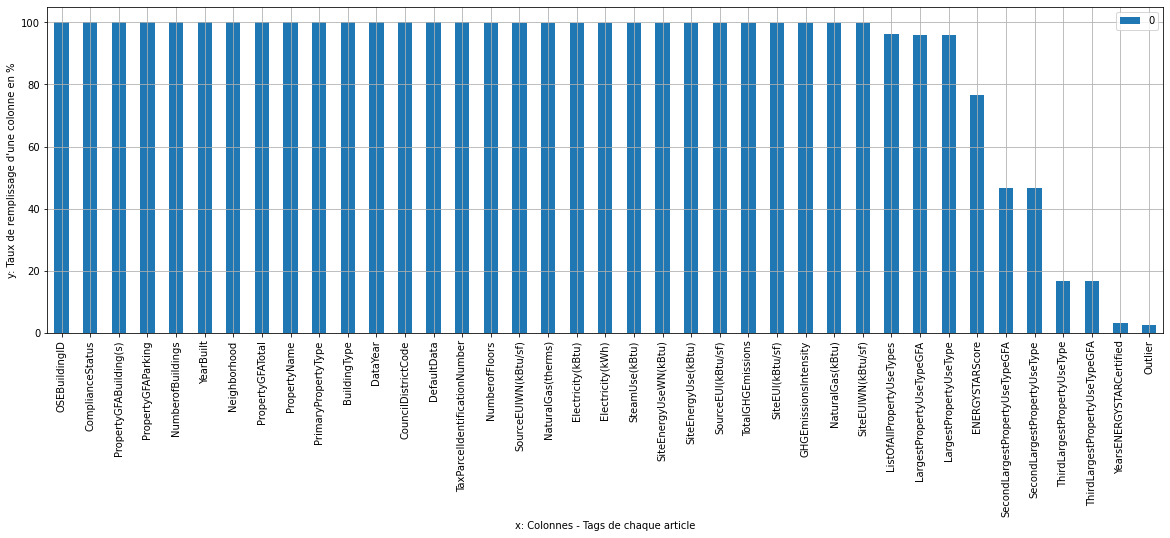

,0
OSEBuildingID,100.000000
ComplianceStatus,100.000000
PropertyGFABuilding(s),100.000000
PropertyGFAParking,100.000000
NumberofBuildings,100.000000
YearBuilt,100.000000
Neighborhood,100.000000
PropertyGFATotal,100.000000
PropertyName,100.000000
PrimaryPropertyType,100.000000


In [23]:
fillrate(data_2015[list_col],1)

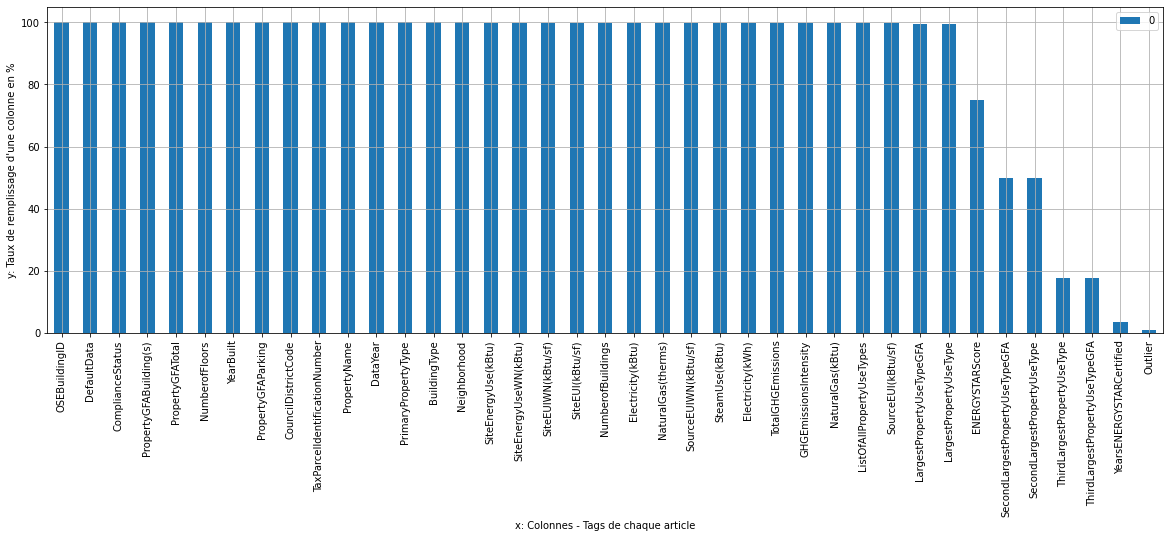

,0
OSEBuildingID,100.000000
DefaultData,100.000000
ComplianceStatus,100.000000
PropertyGFABuilding(s),100.000000
PropertyGFATotal,100.000000
NumberofFloors,100.000000
YearBuilt,100.000000
PropertyGFAParking,100.000000
CouncilDistrictCode,100.000000
TaxParcelIdentificationNumber,100.000000


In [24]:
fillrate(data_2016[list_col],1)

Leur taux de remplissage par colonnes est quasi identique pour les deux dataset.  
On va récupérer les bâtiments de data_2015 qui ne sont pas dans data_2016 à partir de leur identifiant unique, à savoir "OSEBuildingID", et les insérer dans la base de données 2016, pour créer un nouveau dataset plus complet de données.

In [25]:
id2015 = data_2015["OSEBuildingID"].values
id2015

array([    1,     2,     3, ..., 50057, 50058, 50059], dtype=int64)

In [26]:
id2016 = data_2016["OSEBuildingID"].values
id2016

array([    1,     2,     3, ..., 50224, 50225, 50226], dtype=int64)

In [33]:
# list de OSEBuildingID contenues dans data_2015 mais pas dans data_2016
list_id_2015 = diff_list(id2015,id2016)
len(list_id_2015)

56

In [34]:
#list_id_2015

In [35]:
# Liste de liste des indices des éléments dans data_2015 mais pas dans data_2016
new_list_bis = []
for value in list_id_2015:
    elt = data_2015.index[data_2015['OSEBuildingID']==value].tolist()
    new_list_bis.append(elt)

In [36]:
print( "On récupère " + str(len(new_list_bis)) + " nouveaux éléments")

On récupère 56 nouveaux éléments


In [37]:
new_list_bis

[[47],
 [165],
 [204],
 [272],
 [312],
 [358],
 [405],
 [406],
 [498],
 [530],
 [593],
 [627],
 [702],
 [703],
 [756],
 [808],
 [823],
 [848],
 [901],
 [1066],
 [1213],
 [1305],
 [1349],
 [1404],
 [1451],
 [1522],
 [1531],
 [1576],
 [1577],
 [1627],
 [1720],
 [1773],
 [1945],
 [2008],
 [2045],
 [2055],
 [2108],
 [2217],
 [2262],
 [2287],
 [2408],
 [2455],
 [2466],
 [2487],
 [2520],
 [2818],
 [2924],
 [2991],
 [3016],
 [3020],
 [3037],
 [3086],
 [3107],
 [3114],
 [3235],
 [3272]]

In [38]:
# Liste des indices des éléments dans data_2015 mais pas dans data_2016
# using list comprehension
flat_ls = [item for sublist in new_list_bis for item in sublist]
flat_ls

[47,
 165,
 204,
 272,
 312,
 358,
 405,
 406,
 498,
 530,
 593,
 627,
 702,
 703,
 756,
 808,
 823,
 848,
 901,
 1066,
 1213,
 1305,
 1349,
 1404,
 1451,
 1522,
 1531,
 1576,
 1577,
 1627,
 1720,
 1773,
 1945,
 2008,
 2045,
 2055,
 2108,
 2217,
 2262,
 2287,
 2408,
 2455,
 2466,
 2487,
 2520,
 2818,
 2924,
 2991,
 3016,
 3020,
 3037,
 3086,
 3107,
 3114,
 3235,
 3272]

In [39]:
# new_list_bis.flatten(order='F')

In [40]:
data_2015.loc[flat_ls]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,TaxParcelIdentificationNumber,Location,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),OtherFuelUse(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,DefaultData,Comment,ComplianceStatus,Outlier,2010 Census Tracts,Seattle Police Department Micro Community Policing Plan Areas,City Council Districts,SPD Beats,Zip Codes
47,61,2015,Multifamily LR (1-4),Low-Rise Multifamily,GATEWOOD APTS,1975700600,"{'latitude': '47.60973588', 'longitude': '-122...",7,DOWNTOWN,1900,1,4.0,48383,0,48383,"Multifamily Housing, Retail Store",Multifamily Housing,38172.0,Retail Store,10211.0,NaN,NaN,NaN,75.0,61.0,69.9,129.6,139.4,2953338.0,3379678.0,915977.0,424619.0,1448859.0,5886.0,588563.0,0.0,112.06,2.19,No,NaN,Compliant,NaN,NaN,14.0,NaN,30.0,18081
165,266,2015,Multifamily LR (1-4),Low-Rise Multifamily,WEST SEATTLE COMM. RESOURCE CENTER/FOOD BANK A...,9271000000,"{'latitude': '47.54423839', 'longitude': '-122...",1,DELRIDGE,2007,1,4.0,52134,0,52134,Multifamily Housing,Multifamily Housing,52134.0,NaN,NaN,NaN,NaN,NaN,85.0,23.3,26.3,73.0,82.5,1212551.0,1369895.0,0.0,355378.0,1212601.0,0.0,0.0,0.0,8.45,0.06,Yes,NaN,Compliant,NaN,NaN,24.0,NaN,51.0,19581
204,325,2015,NonResidential,Retail Store,WESTLAKE MALL RETAIL PORTION,659000005,"{'latitude': '47.61171108', 'longitude': '-122...",7,DOWNTOWN,1989,1,4.0,111077,0,111077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.0,60.6,62.1,190.2,195.1,9898724.0,10155788.0,0.0,2901150.0,9899135.0,0.0,0.0,0.0,69.01,0.24,No,NaN,Compliant,NaN,NaN,14.0,NaN,31.0,18081
272,400,2015,NonResidential,Small- and Mid-Sized Office,GALLAND & SENECA BUILDINGS,1974700175,"{'latitude': '47.60679898', 'longitude': '-122...",7,DOWNTOWN,1906,1,6.0,98370,25920,72450,Office,Office,98370.0,NaN,NaN,NaN,NaN,NaN,45.0,66.3,66.5,207.5,207.7,6525887.0,6541579.0,0.0,1901522.0,6488262.0,379.0,37893.0,0.0,47.24,0.20,No,NaN,Compliant,NaN,NaN,14.0,NaN,30.0,18081
312,442,2015,NonResidential,Large Office,KING BROADCASTING,1991200870,"{'latitude': '47.6214758', 'longitude': '-122....",7,LAKE UNION,1947,1,4.0,193788,37854,155934,"Data Center, Office, Other, Parking, Restaurant",Office,138672.0,Parking,47539.0,Other,11166.0,NaN,59.0,105.8,104.0,332.3,326.4,16760217.0,16463978.0,0.0,4912139.0,16760914.0,0.0,0.0,0.0,116.84,0.23,No,NaN,Compliant,NaN,NaN,56.0,NaN,7.0,18390
358,499,2015,NonResidential,Small- and Mid-Sized Office,ASIAN COUNSELING and REFERRAL SERVICE BUILDING,1426300170,"{'latitude': '47.57089656', 'longitude': '-122...",2,GREATER DUWAMISH,2008,1,3.0,76598,21410,55188,"Office, Parking",Office,55188.0,Parking,21410.0,NaN,NaN,NaN,76.0,81.1,83.7,169.8,166.9,4476997.0,4617864.0,0.0,654779.0,2234200.0,22429.0,2242889.0,0.0,134.69,1.63,Yes,NaN,Compliant,NaN,NaN,10.0,NaN,42.0,18388
405,559,2015,NonResidential,Large Office,YALE & THOMAS,6847700105,"{'latitude': '47.6212428', 'longitude': '-122....",7,LAKE UNION,1981,1,4.0,186971,0,186971,"Office, Parking",Office,186977.0,Parking,115477.0,NaN,NaN,NaN,86.0,67.7,72.6,179.1,184.2,12662456.0,13575377.0,0.0,2830466.0,9657951.0,30049.0,3004906.0,0.0,226.92,0.99,No,NaN,Compliant,NaN,NaN,56.0,NaN,10.0,18390
406,560,2015,NonResidential,Non-Refrigerated Warehouse,EVERGREEN WHLSLE FLORIST (DEMOLISHED),6849200005,"{'latitude': '47.62145274', 'longitude': '-122...",7,LAKE UNION,1955,1,1.0,66968,0,66968,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,23.5,23.5,73.8,73.8,1575581.0,1575581.0,0.0,461096.0,1573323.0,23.0,2323.0,0.0,11.09,0.06,No,NaN,Compliant,NaN,N

On crée ce nouveau dataset:

In [131]:
# Ajout des lignes 2015 avec les lignes 2016 dans un nouveau dataset
data = pd.concat([data_2015.loc[flat_ls][list_col],data_2016[list_col]],axis=0)
data.shape

(3432, 39)

In [132]:
data.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,DefaultData,ComplianceStatus,Outlier
47,61,2015,Multifamily LR (1-4),Low-Rise Multifamily,GATEWOOD APTS,1975700600,7,DOWNTOWN,1900,1.0,4.0,48383,0,48383,"Multifamily Housing, Retail Store",Multifamily Housing,38172.0,Retail Store,10211.0,NaN,NaN,NaN,75.0,61.0,69.9,129.6,139.4,2953338.0,3379678.0,915977.0,424619.0,1448859.0,5886.0,588563.0,112.06,2.19,No,Compliant,NaN
165,266,2015,Multifamily LR (1-4),Low-Rise Multifamily,WEST SEATTLE COMM. RESOURCE CENTER/FOOD BANK A...,9271000000,1,DELRIDGE,2007,1.0,4.0,52134,0,52134,Multifamily Housing,Multifamily Housing,52134.0,NaN,NaN,NaN,NaN,NaN,85.0,23.3,26.3,73.0,82.5,1212551.0,1369895.0,0.0,355378.0,1212601.0,0.0,0.0,8.45,0.06,Yes,Compliant,NaN
204,325,2015,NonResidential,Retail Store,WESTLAKE MALL RETAIL PORTION,659000005,7,DOWNTOWN,1989,1.0,4.0,111077,0,111077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.0,60.6,62.1,190.2,195.1,9898724.0,10155788.0,0.0,2901150.0,9899135.0,0.0,0.0,69.01,0.24,No,Compliant,NaN
272,400,2015,NonResidential,Small- and Mid-Sized Office,GALLAND & SENECA BUILDINGS,1974700175,7,DOWNTOWN,1906,1.0,6.0,98370,25920,72450,Office,Office,98370.0,NaN,NaN,NaN,NaN,NaN,45.0,66.3,66.5,207.5,207.7,6525887.0,6541579.0,0.0,1901522.0,6488262.0,379.0,37893.0,47.24,0.20,No,Compliant,NaN
312,442,2015,NonResidential,Large Office,KING BROADCASTING,1991200870,7,LAKE UNION,1947,1.0,4.0,193788,37854,155934,"Data Center, Office, Other, Parking, Restaurant",Office,138672.0,Parking,47539.0,Other,11166.0,NaN,59.0,105.8,104.0,332.3,326.4,16760217.0,16463978.0,0.0,4912139.0,16760914.0,0.0,0.0,116.84,0.23,No,Compliant,NaN


In [133]:
data.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode',
       'Neighborhood', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors',
       'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified',
       'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)',
       'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)',
       'TotalGHGEmissions', 'GHGEmissionsIntensity', 'DefaultData',
       'ComplianceStatus', 'Outlier'],
      dtype='object')

# Gestion des doublons  
L'identifiant unique d'un bâtiment de la base de données est donnée par la colonne "OSEBuildingID".


In [134]:
# OSEBuildingID représente l'identifiant unique d'un bâtiment de la base de données.
data[data['OSEBuildingID'].duplicated(keep=False)]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,DefaultData,ComplianceStatus,Outlier


Il n'y a pas de doublons au niveau de la clé primaire dans cette base de données.

# Analyse univariée  
On va séparer les colonnes de données quantitatives des données qualitatives et réaliser des analyses pour chaque type de données:

In [135]:
list_data_num = data.describe().columns
list_data_num

Index(['OSEBuildingID', 'DataYear', 'CouncilDistrictCode', 'YearBuilt',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'TotalGHGEmissions', 'GHGEmissionsIntensity'],
      dtype='object')

Parmis ces données numériques, les colonnes ['OSEBuildingID', 'DataYear', 'CouncilDistrictCode'] représentent des données qualitatives. On a donc:

In [136]:
list_data_quanti = [ 'YearBuilt','NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'TotalGHGEmissions', 'GHGEmissionsIntensity']

In [137]:
len(list_data_quanti)

23

In [138]:
list_data_col = data.columns

list_data_quali = [icol for icol in list_data_col if icol not in list_data_quanti]
list_data_quali

['OSEBuildingID',
 'DataYear',
 'BuildingType',
 'PrimaryPropertyType',
 'PropertyName',
 'TaxParcelIdentificationNumber',
 'CouncilDistrictCode',
 'Neighborhood',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'SecondLargestPropertyUseType',
 'ThirdLargestPropertyUseType',
 'YearsENERGYSTARCertified',
 'DefaultData',
 'ComplianceStatus',
 'Outlier']

In [139]:
len(list_data_quali)

16

## Analyse des données qualitatives
### Choix des colonnes qualitatives

In [140]:
data[list_data_quali].head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,ListOfAllPropertyUseTypes,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,YearsENERGYSTARCertified,DefaultData,ComplianceStatus,Outlier
47,61,2015,Multifamily LR (1-4),Low-Rise Multifamily,GATEWOOD APTS,1975700600,7,DOWNTOWN,"Multifamily Housing, Retail Store",Multifamily Housing,Retail Store,NaN,NaN,No,Compliant,NaN
165,266,2015,Multifamily LR (1-4),Low-Rise Multifamily,WEST SEATTLE COMM. RESOURCE CENTER/FOOD BANK A...,9271000000,1,DELRIDGE,Multifamily Housing,Multifamily Housing,NaN,NaN,NaN,Yes,Compliant,NaN
204,325,2015,NonResidential,Retail Store,WESTLAKE MALL RETAIL PORTION,659000005,7,DOWNTOWN,NaN,NaN,NaN,NaN,NaN,No,Compliant,NaN
272,400,2015,NonResidential,Small- and Mid-Sized Office,GALLAND & SENECA BUILDINGS,1974700175,7,DOWNTOWN,Office,Office,NaN,NaN,NaN,No,Compliant,NaN
312,442,2015,NonResidential,Large Office,KING BROADCASTING,1991200870,7,LAKE UNION,"Data Center, Office, Other, Parking, Restaurant",Office,Parking,Other,NaN,No,Compliant,NaN


In [141]:
# data[list_data_quali].loc[data[list_data_quali].isnull().sum(axis=1) ==1] #Lignes ne possédant aucune valeur manquante

Notre objectif étant de prédire l'énergie consommée par un bâtiment, les colonnes "PropertyName, TaxParcelIdentificationNumber, Neighborhood, YearsENERGYSTARCertified, DefaultData, ComplianceStatus, Outlier" ne semblent pas nous être utiles.  
Ensuite, cas par cas:
- BuildingType: Nous informe si le bâtiment est une zone résidentielle, et donc pourra consommer de l'énergie si c'est le cas.
- PrimaryPropertyType, SecondLargestPropertyUseType, SecondLargestPropertyUseType et ListOfAllPropertyUseTypes: Le type d'utilisation du bâtiment peut impacter sur le taux de consommation énergétique. --> A voir si on les gardes toutes ou une seule de ces colonnes.  

Supprimons celles qui ne nous intéressent pas et observons plus minutieusement les autres:

In [142]:
col_quali_drop = ["OSEBuildingID","DataYear","PropertyName", "TaxParcelIdentificationNumber", "Neighborhood", "YearsENERGYSTARCertified", "DefaultData", "ComplianceStatus", "Outlier"]
data.drop(col_quali_drop,inplace=True,axis=1)

Redéterminons les colonnes de données qualitatives:

In [143]:
list_data_col = data.columns
list_data_quali = [icol for icol in list_data_col if icol not in list_data_quanti]
list_data_quali

['BuildingType',
 'PrimaryPropertyType',
 'CouncilDistrictCode',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'SecondLargestPropertyUseType',
 'ThirdLargestPropertyUseType']

In [144]:
data[list_data_quali].head()

,BuildingType,PrimaryPropertyType,CouncilDistrictCode,ListOfAllPropertyUseTypes,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType
47,Multifamily LR (1-4),Low-Rise Multifamily,7,"Multifamily Housing, Retail Store",Multifamily Housing,Retail Store,NaN
165,Multifamily LR (1-4),Low-Rise Multifamily,1,Multifamily Housing,Multifamily Housing,NaN,NaN
204,NonResidential,Retail Store,7,NaN,NaN,NaN,NaN
272,NonResidential,Small- and Mid-Sized Office,7,Office,Office,NaN,NaN
312,NonResidential,Large Office,7,"Data Center, Office, Other, Parking, Restaurant",Office,Parking,Other


In [145]:
def compare_cat(dataframe,categorisation):
    result = np.array([])
    for icat in categorisation:
        comptage_freq_cat = round(dataframe[icat].nunique())
        result = np.append(result,comptage_freq_cat)
    #ser = pd.Series(result,index=list_subcat,name=dataColumn)
    minidata = pd.DataFrame([result],columns = categorisation)
    ax = minidata.plot.bar(figsize = (12,6)) #.sort_values()
    for p in ax.patches:
        ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))
    #plt.bar(categorisation,result)
    #plt.legend()plt.grid()
    plt.xlabel("x: Type de catégorisation")
    plt.ylabel("y: Nombre de sous catégories différentes dans chaque type de catégorisation")
    plt.show()

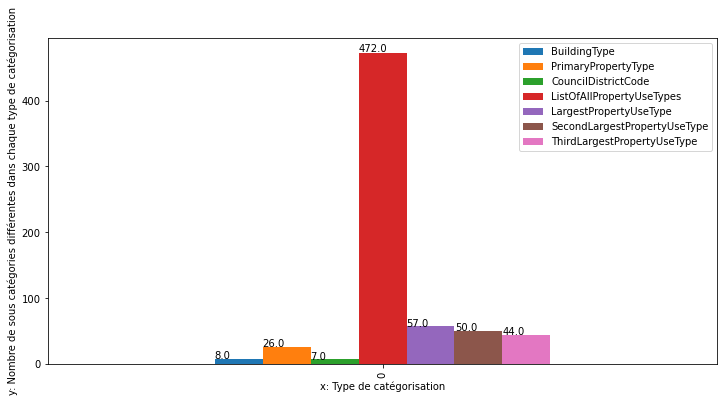

In [146]:
compare_cat(data,list_data_quali)

La colonne "ListOfAllPropertyUseTypes" possède des valeurs sous formes de listes des valeurs de "LargestPropertyUseType", "SecondLargestPropertyUseType" et "ThirdLargestPropertyUseType". Cette liste serait difficilement utilisable dans cet état, et notamment avec 466 valeurs différentes.  
Un Nan dans les colonnes "SecondLargestPropertyUseType" et "ThirdLargestPropertyUseType" veut dire qu'il n'y a pas d'utilsation secondaire ou tertiere du bâtiment.  __Serait-il judicieux de remplacer les nan par des labels comme "Not Used"?__
Regardons de quoi sont constitués en détails ces colonnes:

In [147]:
def repart_cat(dataframe,sub_cat,orientation):
    comptage_freq_cat = dataframe[sub_cat].value_counts()
    ax = comptage_freq_cat.plot.bar(figsize = (16,8), sort_columns = True) #.plot(kind='barh')
    plt.xlabel("x: Sous catégories")
    plt.ylabel("y: Fréquence d'apparition")
    plt.title(sub_cat)
    if orientation == 'h':
        for p in ax.patches:
            ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005),rotation='horizontal')
    if orientation == 'v':
        for p in ax.patches:
            ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.4),rotation='vertical')

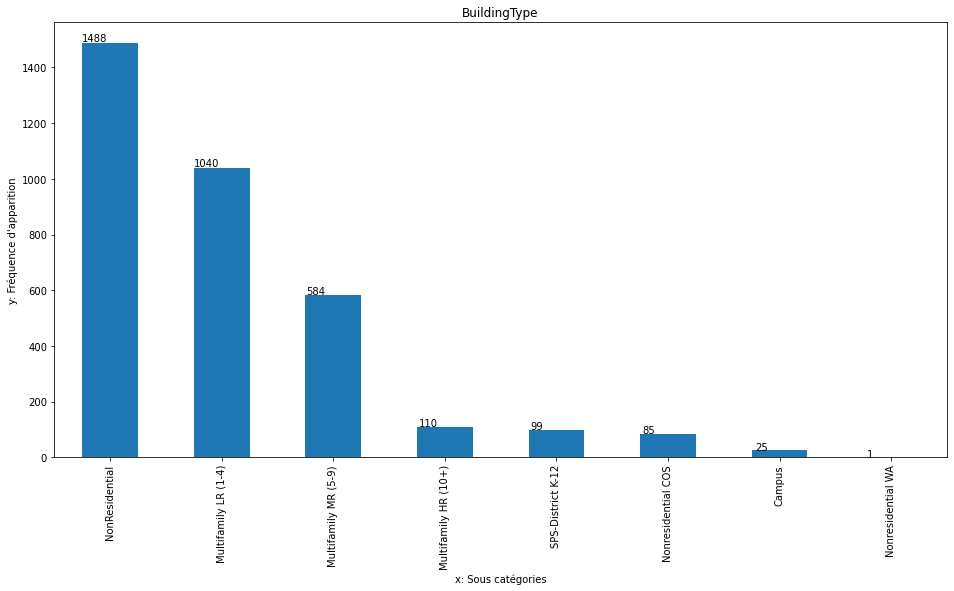

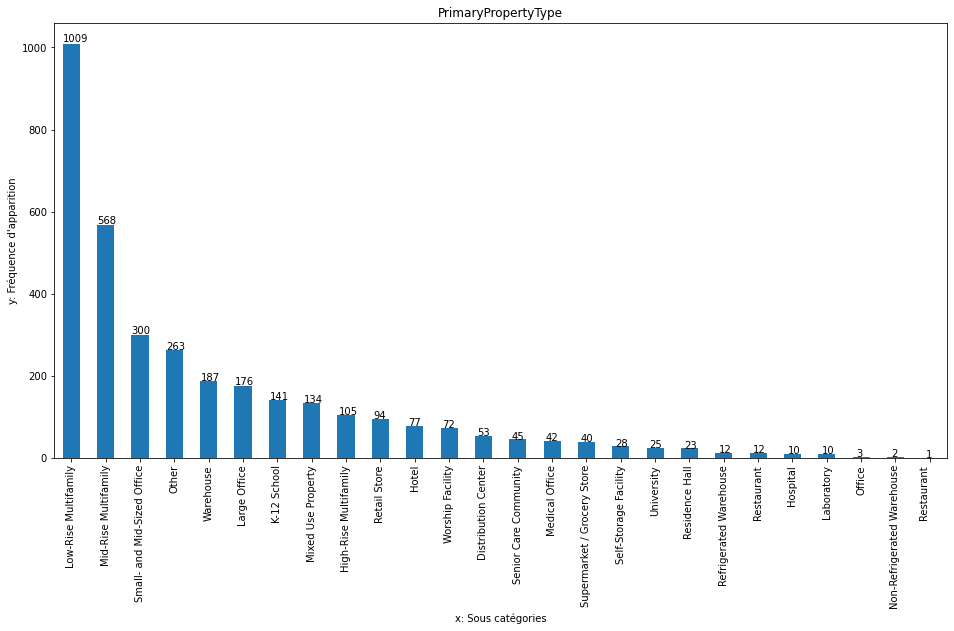

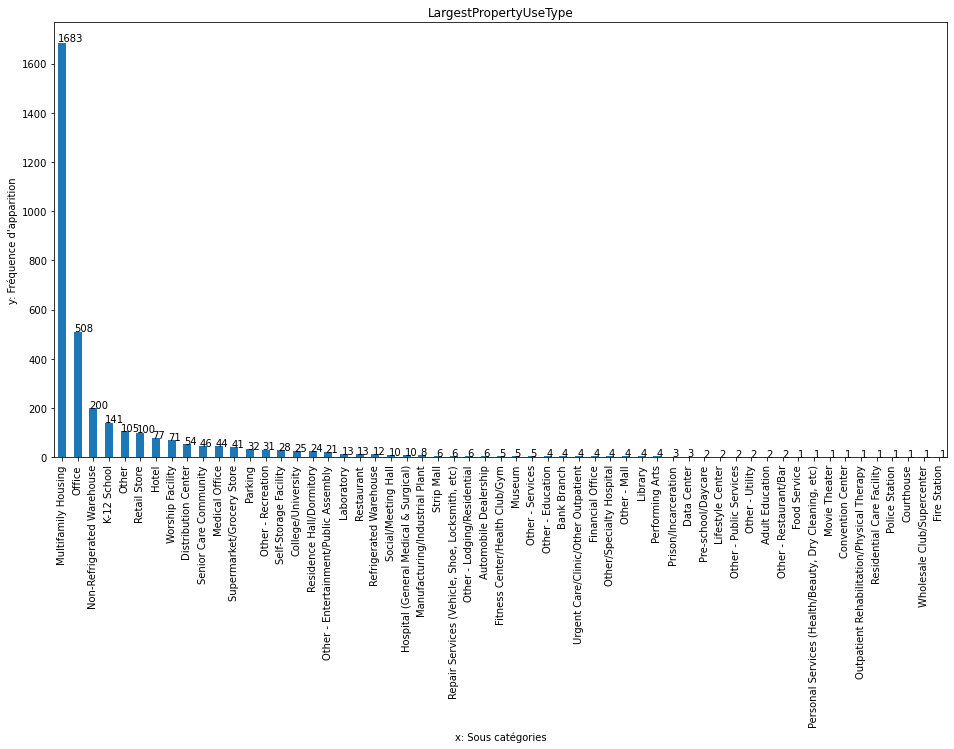

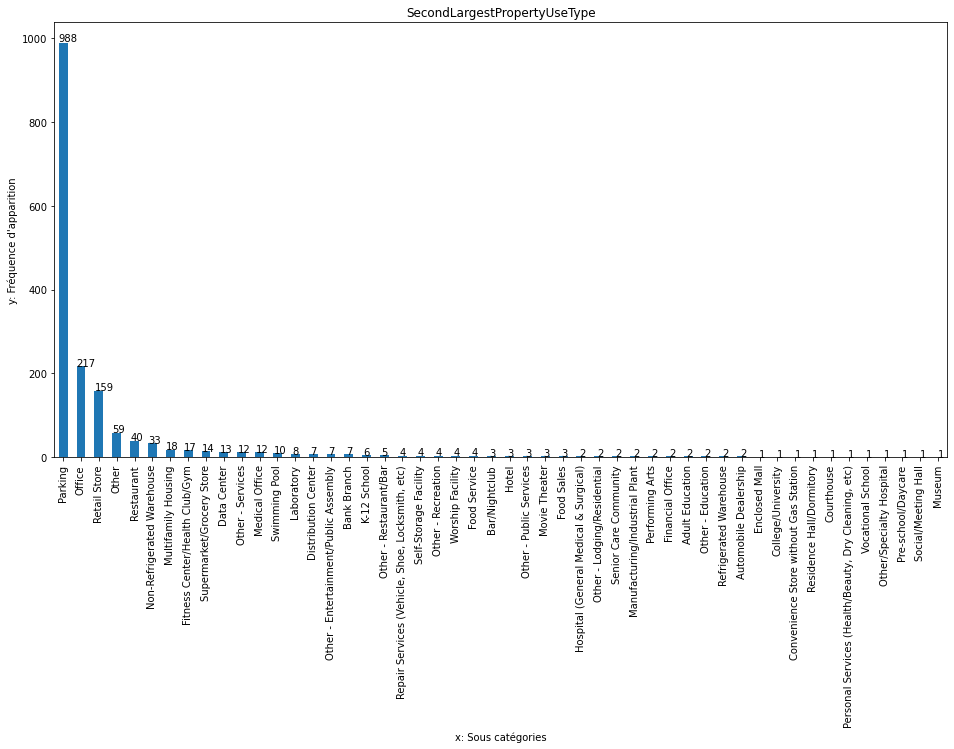

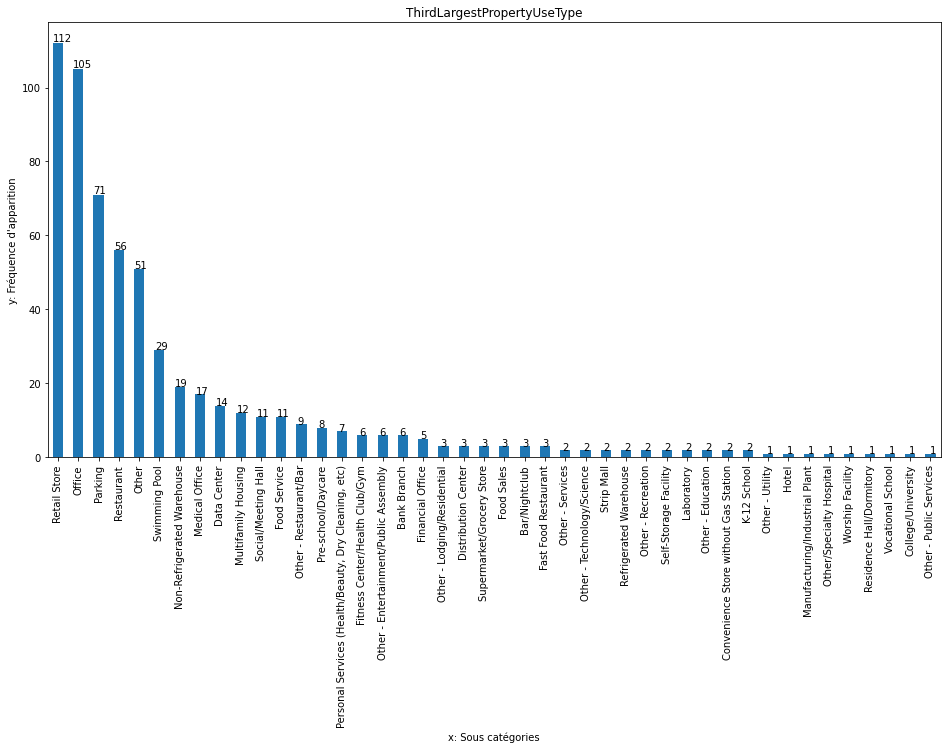

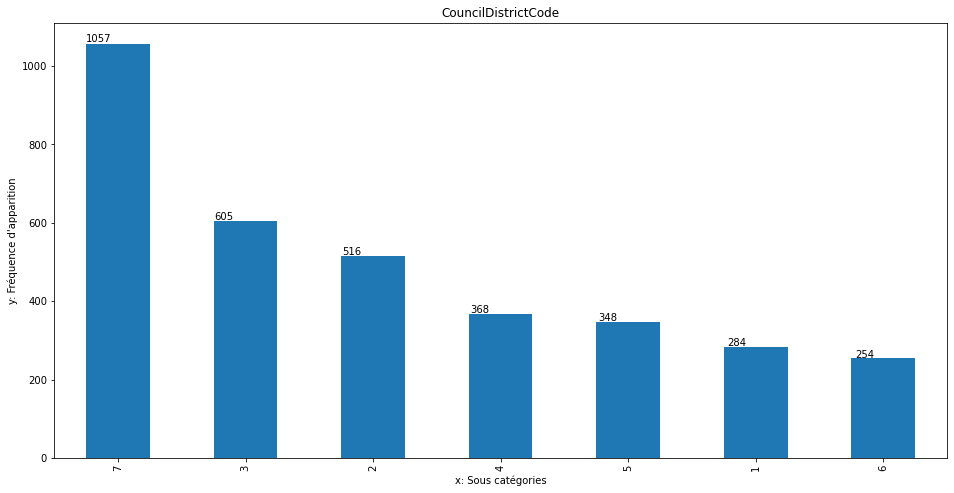

In [58]:
for icol in ['BuildingType', 'PrimaryPropertyType', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType','CouncilDistrictCode']:
    repart_cat(data,icol,'h')
    plt.show()

- BuildingType: Nous donne une idée de la quantité et du type de population présente dans ces bâtiments.
- PropertyType: Nous donne un indice sur le type de bâtiment ou d'utilisation du bâtiment (dont près de 60 labels différents).

Une analyse bivariée (avec Anova?) ou illustrative pourrait nous montrer si en effet, l'énergie relevée des bâtiments dépend de leur type et de la population qui y réside.

In [148]:
list_data_quali_keep = ['BuildingType', 'PrimaryPropertyType', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType','CouncilDistrictCode']

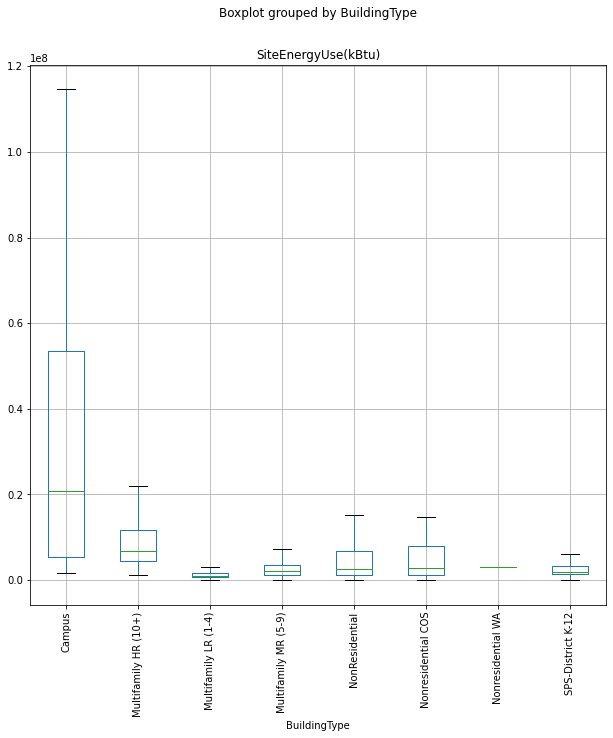

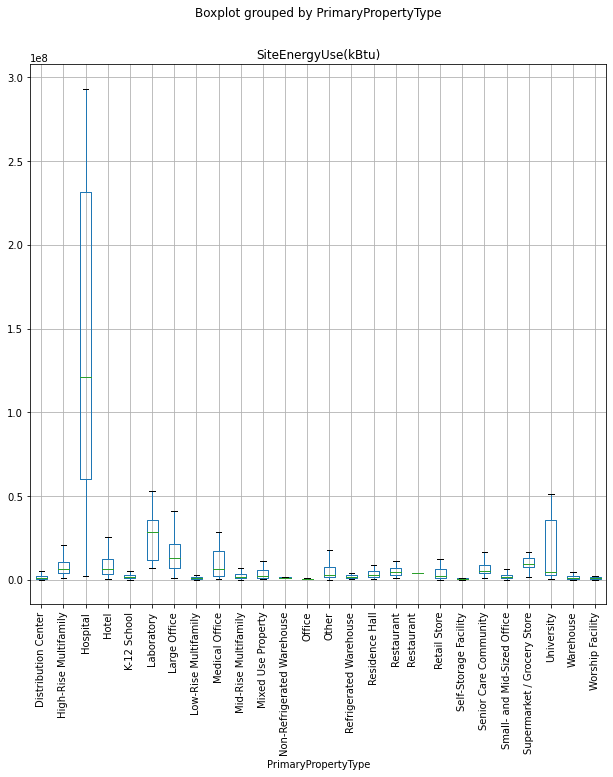

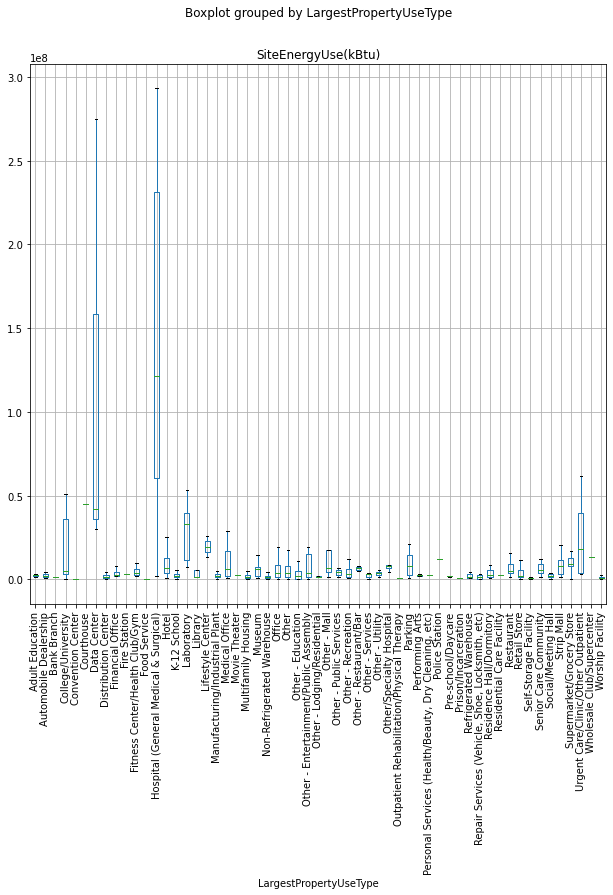

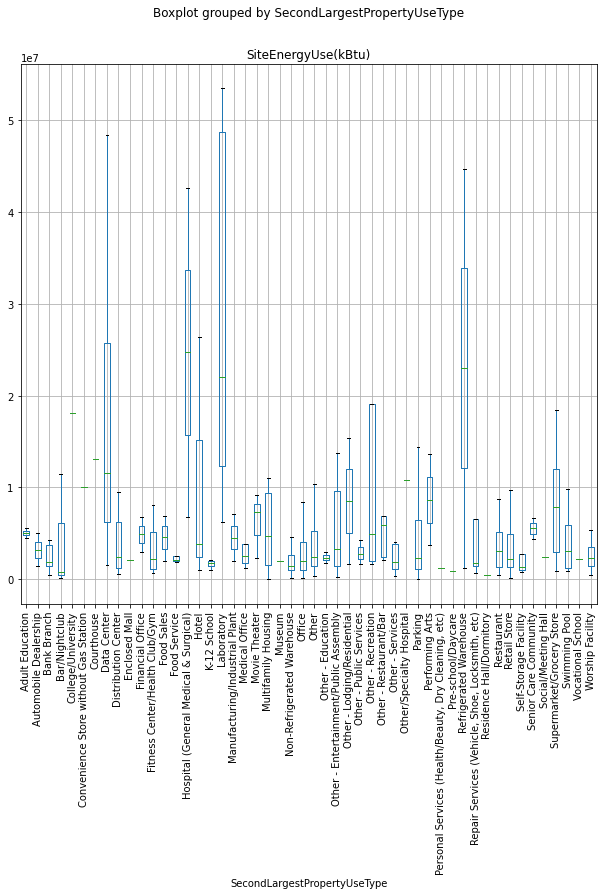

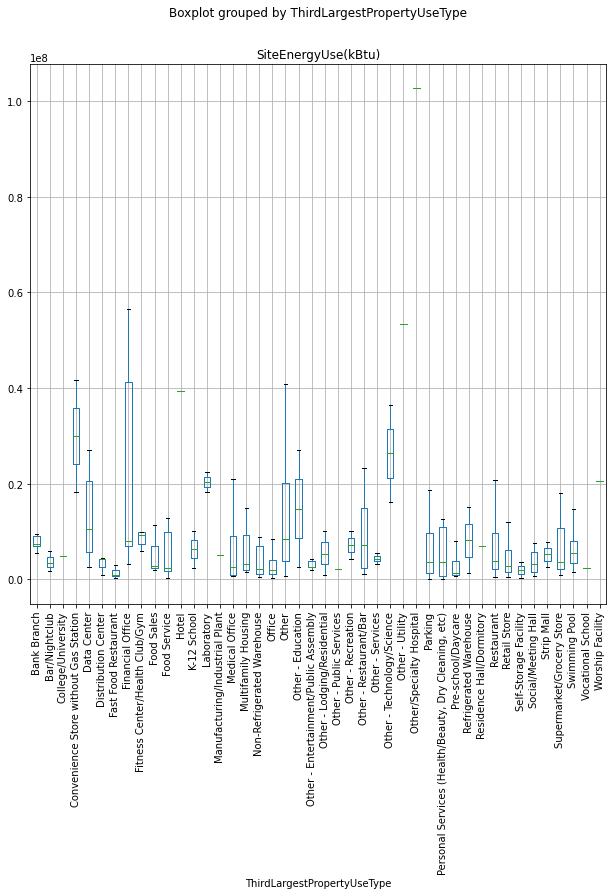

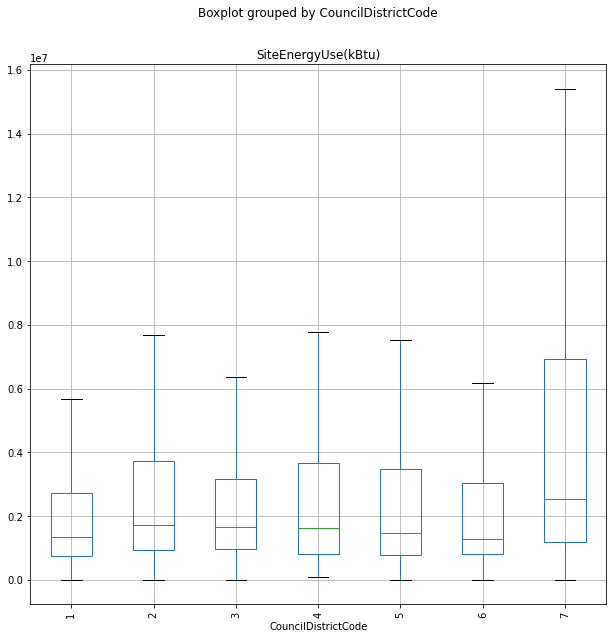

In [61]:
for icol in list_data_quali_keep:
    data.boxplot(column='SiteEnergyUse(kBtu)', by=icol,figsize=(10,10),showfliers=False)
    plt.xticks(rotation=90)
    plt.show()

On a tracé nos boîtes à moustaches sans les outliers pour plus de lisibilité.  
On constate que la variable à prédire "SiteEnergyUse(kBtu)" se répartie différement au sein des différentes données qualitatives. De ce fait, on va garder ces données pour nous aider sur les futurs prédictions.

### Restriction métier du dataset

On rappel que dans l'étude métier, on s’intéresse de près aux émissions des bâtiments non destinés à l’habitation. De ce fait, on va pouvoir enlever les bâtiments qui ne sont pas considérés comme résidentiels, que l'on peut séparer grâce à la colonne "BuildingType".

In [149]:
data[data['BuildingType']=='Nonresidential WA']

,BuildingType,PrimaryPropertyType,CouncilDistrictCode,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
3359,Nonresidential WA,University,4,1962,1.0,1.0,68072,0,68072,College/University,College/University,68916.0,NaN,NaN,NaN,NaN,NaN,46.200001,46.200001,144.899994,144.899994,3180819.25,3180819.25,0.0,932244.6875,3180819.0,0.0,0.0,22.17,0.33


In [150]:
data[data['BuildingType']=='Nonresidential COS']

,BuildingType,PrimaryPropertyType,CouncilDistrictCode,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
5,Nonresidential COS,Other,7,1999,1.0,2.0,97288,37198,60090,Police Station,Police Station,88830.0,NaN,NaN,NaN,NaN,NaN,136.100006,141.600006,316.299988,320.500000,1.208662e+07,1.258171e+07,0.0,2.160444e+06,7.371434e+06,47151.816410,4.715182e+06,301.81,3.10
15,Nonresidential COS,Other,7,2004,1.0,11.0,412000,57000,355000,"Data Center, Library, Parking",Library,364913.0,Parking,49000.0,Data Center,1074.0,NaN,50.799999,51.099998,155.600006,156.000000,1.858886e+07,1.870691e+07,737559.5,5.231916e+06,1.785130e+07,0.000000,0.000000e+00,181.38,0.44
69,Nonresidential COS,Other,7,1962,1.0,1.0,389000,0,389000,Other,Other,368000.0,NaN,NaN,NaN,NaN,NaN,64.300003,64.500000,151.600006,152.100006,2.365898e+07,2.373692e+07,6093150.0,4.226010e+06,1.441915e+07,6886.799805,6.886800e+05,607.41,1.56
70,Nonresidential COS,Other,7,1962,1.0,1.0,91213,0,91213,Other,Other,65000.0,NaN,NaN,NaN,NaN,NaN,125.199997,125.900002,261.700012,265.399994,8.141156e+06,8.181881e+06,4120130.0,1.100268e+06,3.754115e+06,0.000000,0.000000e+00,344.20,3.77
71,Nonresidential COS,Other,7,1938,1.0,5.0,396085,0,396085,Other,Other,278500.0,NaN,NaN,NaN,NaN,NaN,75.199997,76.300003,138.100006,140.000000,2.095503e+07,2.125784e+07,9763690.0,2.125535e+06,7.252325e+06,0.000000,0.000000e+00,804.20,2.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,Nonresidential COS,Office,2,1990,1.0,1.0,12294,0,12294,Office,Office,12294.0,NaN,NaN,NaN,NaN,46.0,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,0.0,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,20.94,1.70
3372,Nonresidential COS,Other,2,2004,1.0,1.0,16000,0,16000,Other - Recreation,Other - Recreation,16000.0,NaN,NaN,NaN,NaN,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.0,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,32.17,2.01
3373,Nonresidential COS,Other,7,1974,1.0,1.0,13157,0,13157,"Fitness Center/Health Club/Gym, Other - Recrea...",Other - Recreation,7583.0,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,NaN,438.200012,460.100006,744.799988,767.799988,5.765898e+06,6.053764e+06,0.0,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,223.54,16.99
3374,Nonresidential COS,Mixed Use Property,1,1989,1.0,1.0,14101,0,14101,"Fitness Center/Health Club/Gym, Food Service, ...",Other - Recreation,6601.0,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,NaN,51.000000,55.500000,105.300003,110.800003,7.194712e+05,7.828413e+05,0.0,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,22.11,1.57


In [151]:
data['BuildingType'].value_counts()

NonResidential          1488
Multifamily LR (1-4)    1040
Multifamily MR (5-9)     584
Multifamily HR (10+)     110
SPS-District K-12         99
Nonresidential COS        85
Campus                    25
Nonresidential WA          1
Name: BuildingType, dtype: int64

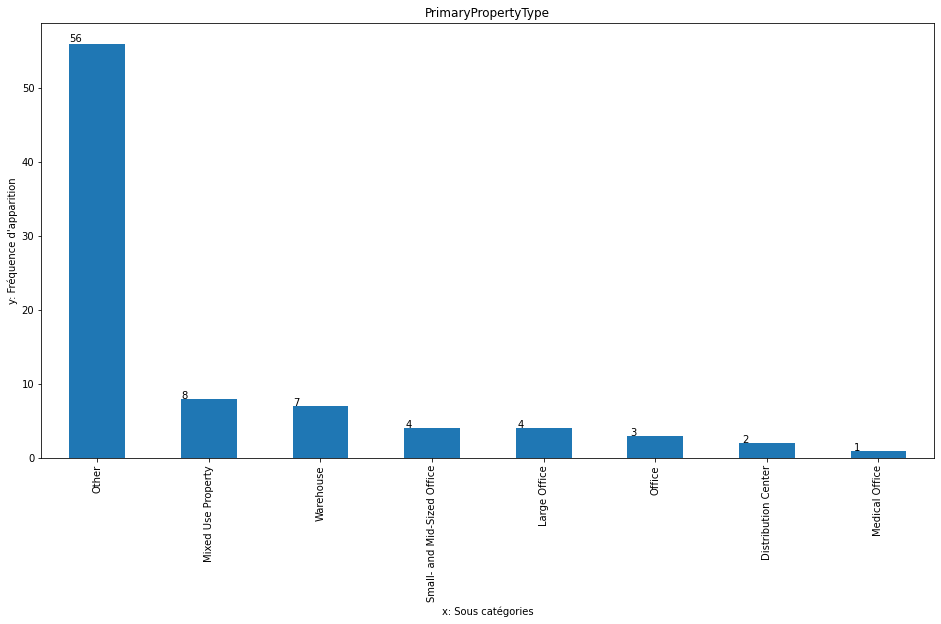

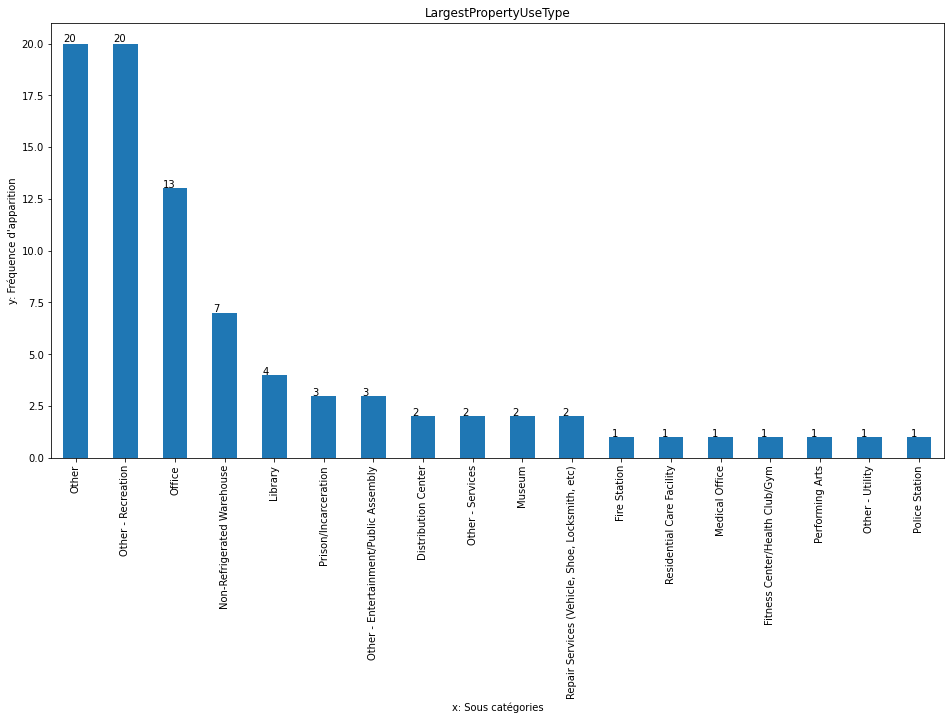

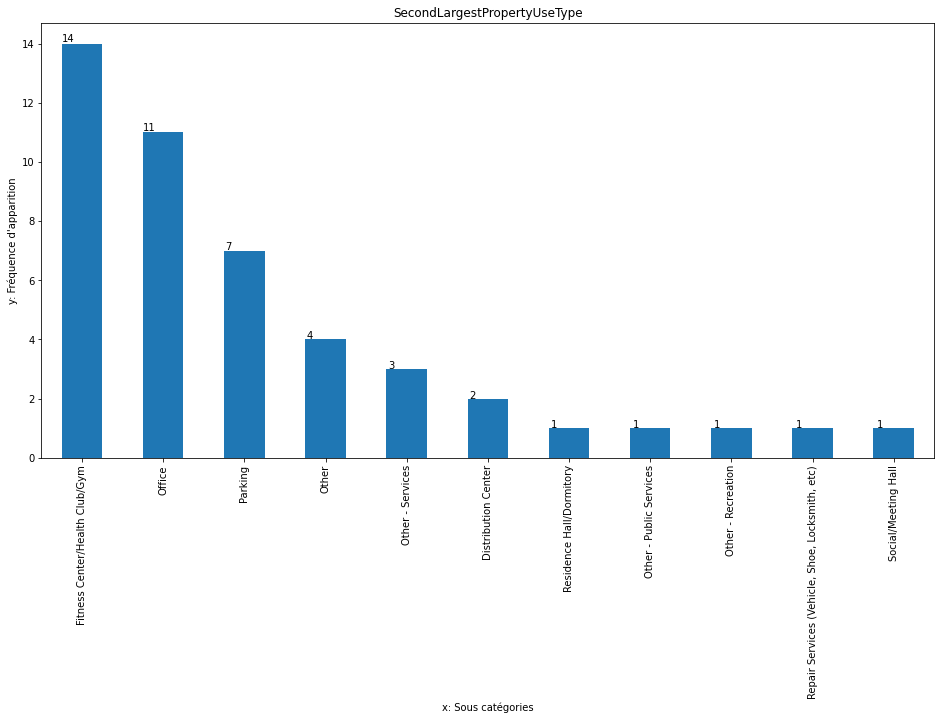

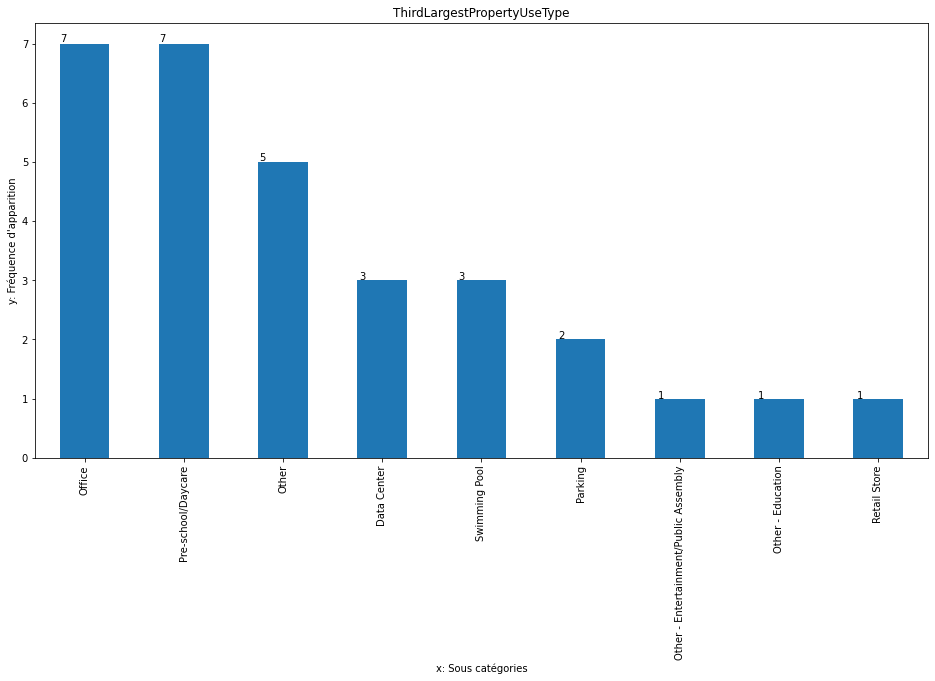

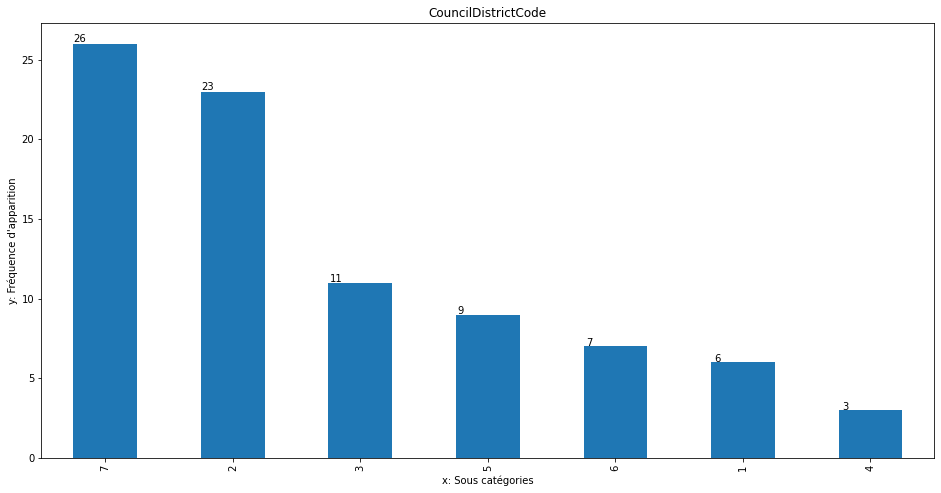

In [65]:
for icol in ['PrimaryPropertyType', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType','CouncilDistrictCode']:
    repart_cat(data[data['BuildingType']=='Nonresidential COS'],icol,'h')
    plt.show()

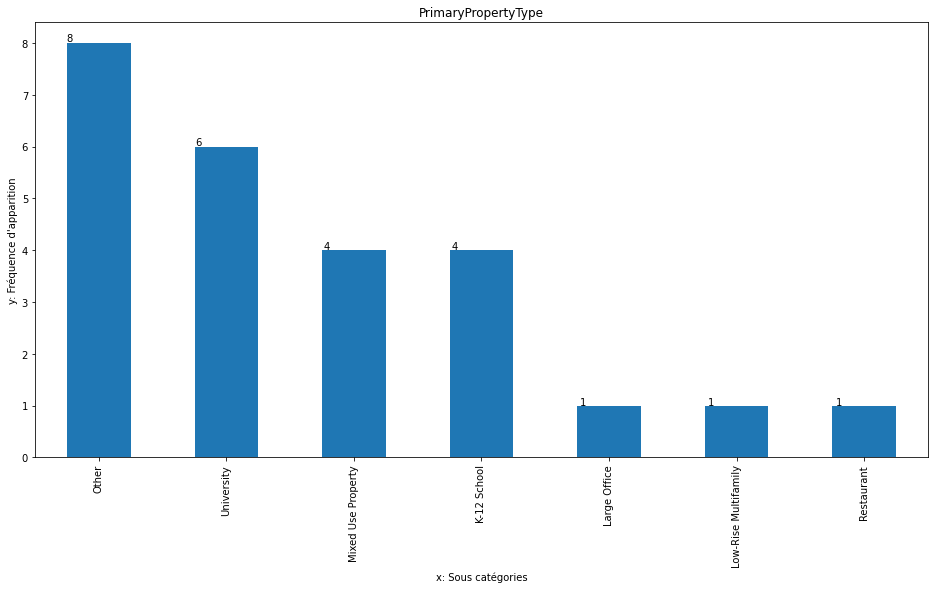

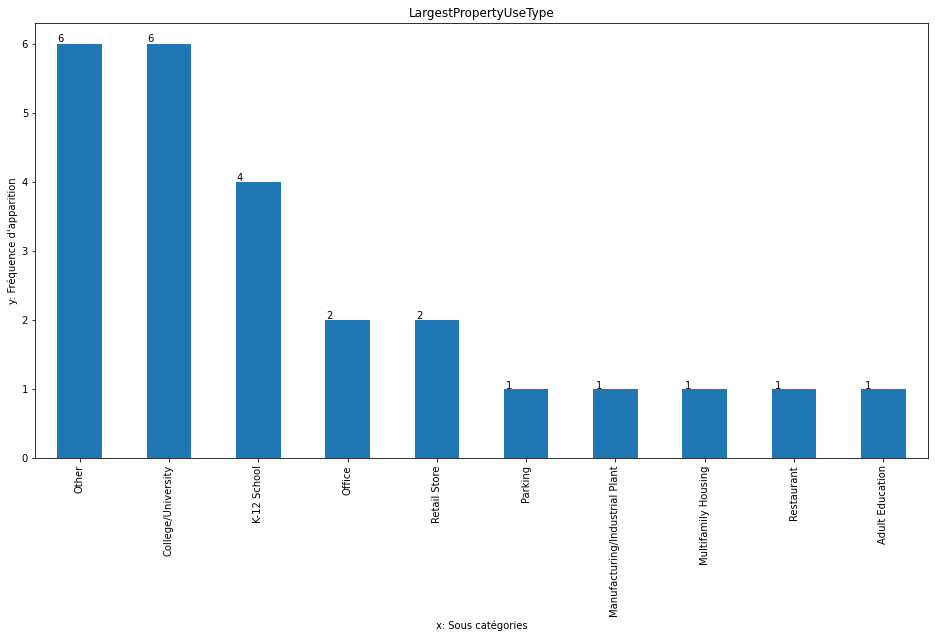

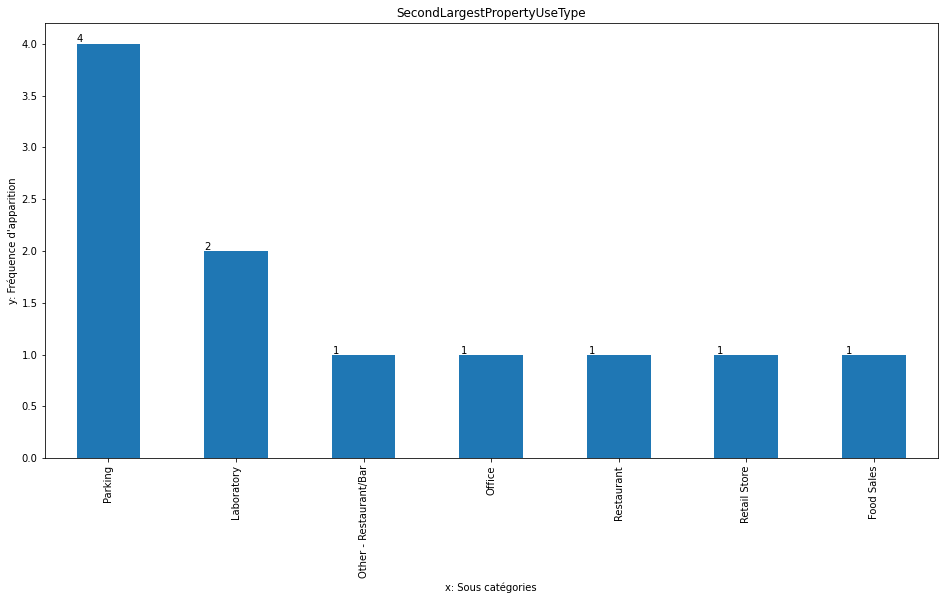

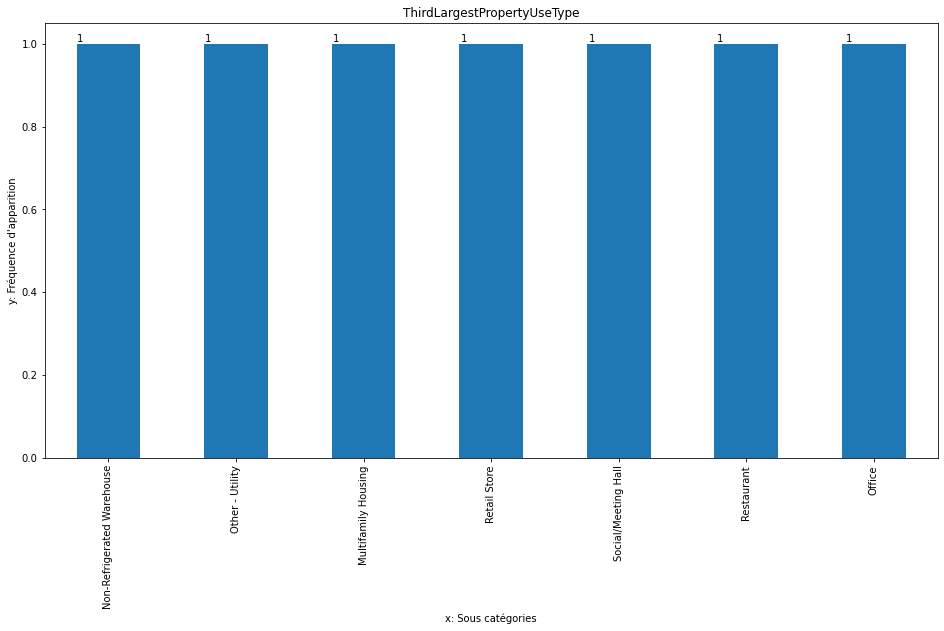

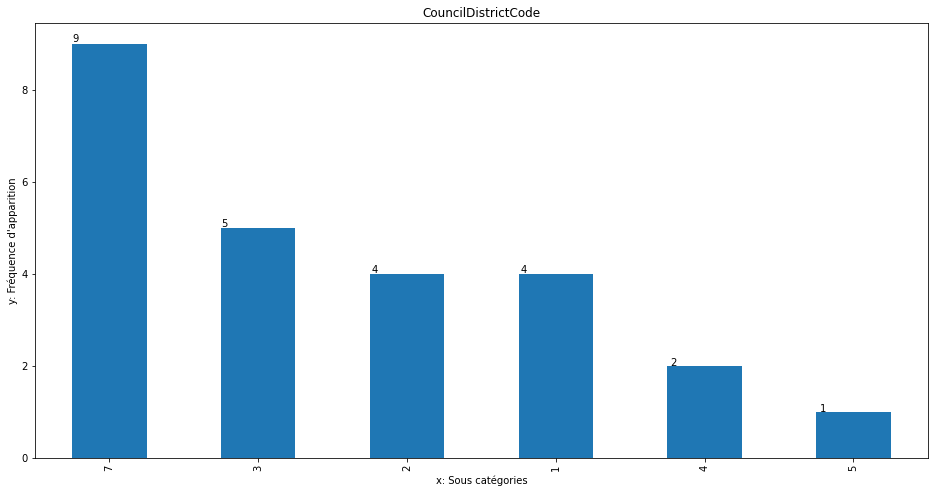

In [66]:
for icol in ['PrimaryPropertyType', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType','CouncilDistrictCode']:
    repart_cat(data[data['BuildingType']=='Campus'],icol,'h')
    plt.show()

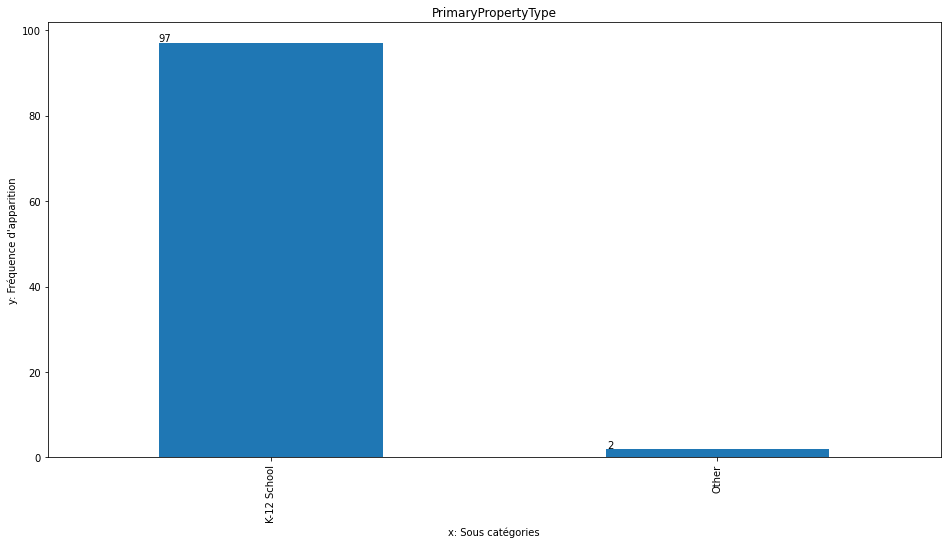

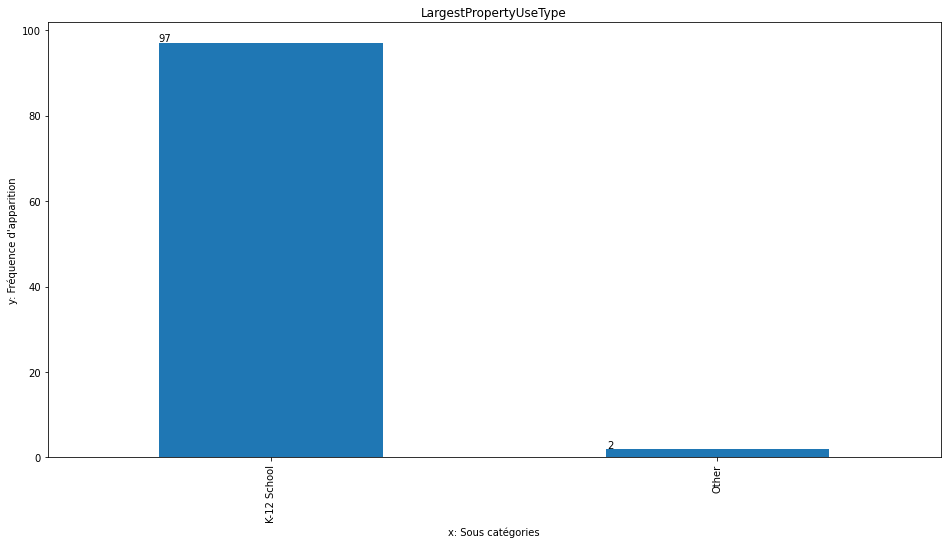

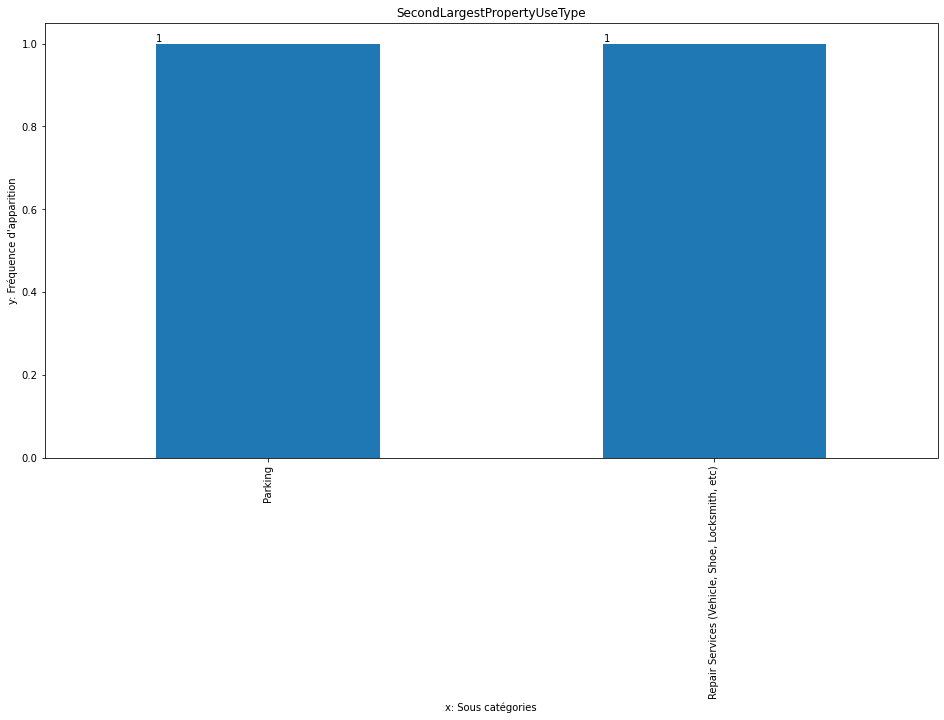

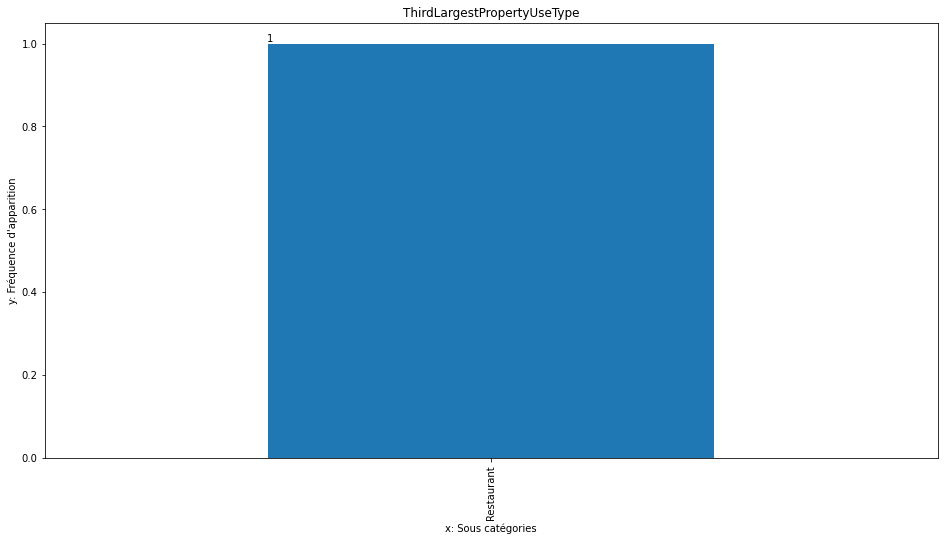

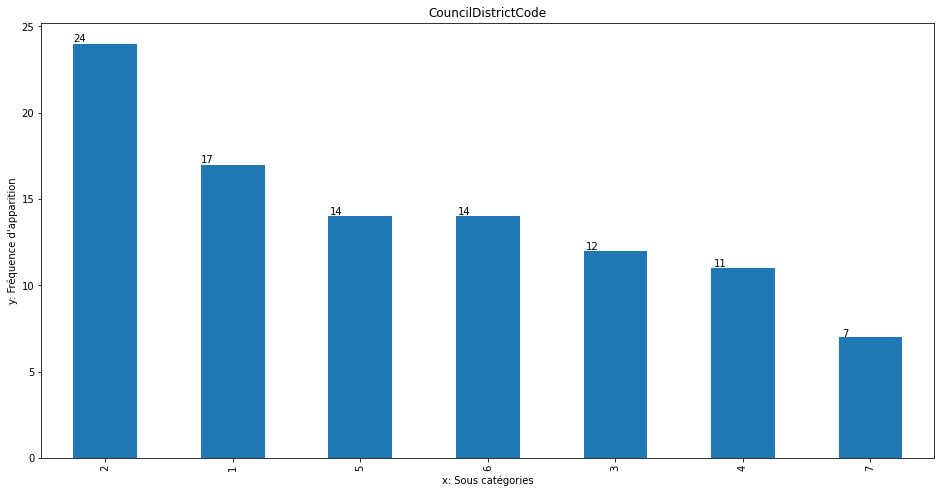

In [67]:
for icol in ['PrimaryPropertyType', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType','CouncilDistrictCode']:
    repart_cat(data[data['BuildingType']=='SPS-District K-12'],icol,'h')
    plt.show()

Après une analyse rapide des types de bâtiment 'Nonresidential WA' et 'Nonresidential COS', ainsi que de 'SPS-District K-12' et 'Campus', on se propose de garder ces colonnes et de supprimer "Multifamily LR (1-4)", "Multifamily MR (5-9)", "Multifamily HR (10+)".

In [68]:
# data[  (data['BuildingType']=='NonResidential') | (data['BuildingType']=='Nonresidential WA') | (data['BuildingType']=='Nonresidential COS')  ]

In [152]:
index_residential_building = data[  (data['BuildingType']=='Multifamily LR (1-4)') | (data['BuildingType']=='Multifamily MR (5-9)') | (data['BuildingType']=='Multifamily HR (10+)')  ].index

In [153]:
data = data.drop(index_residential_building)

In [154]:
data.shape

(1672, 30)

## Analyse des données quantitatives
### Histogrammes

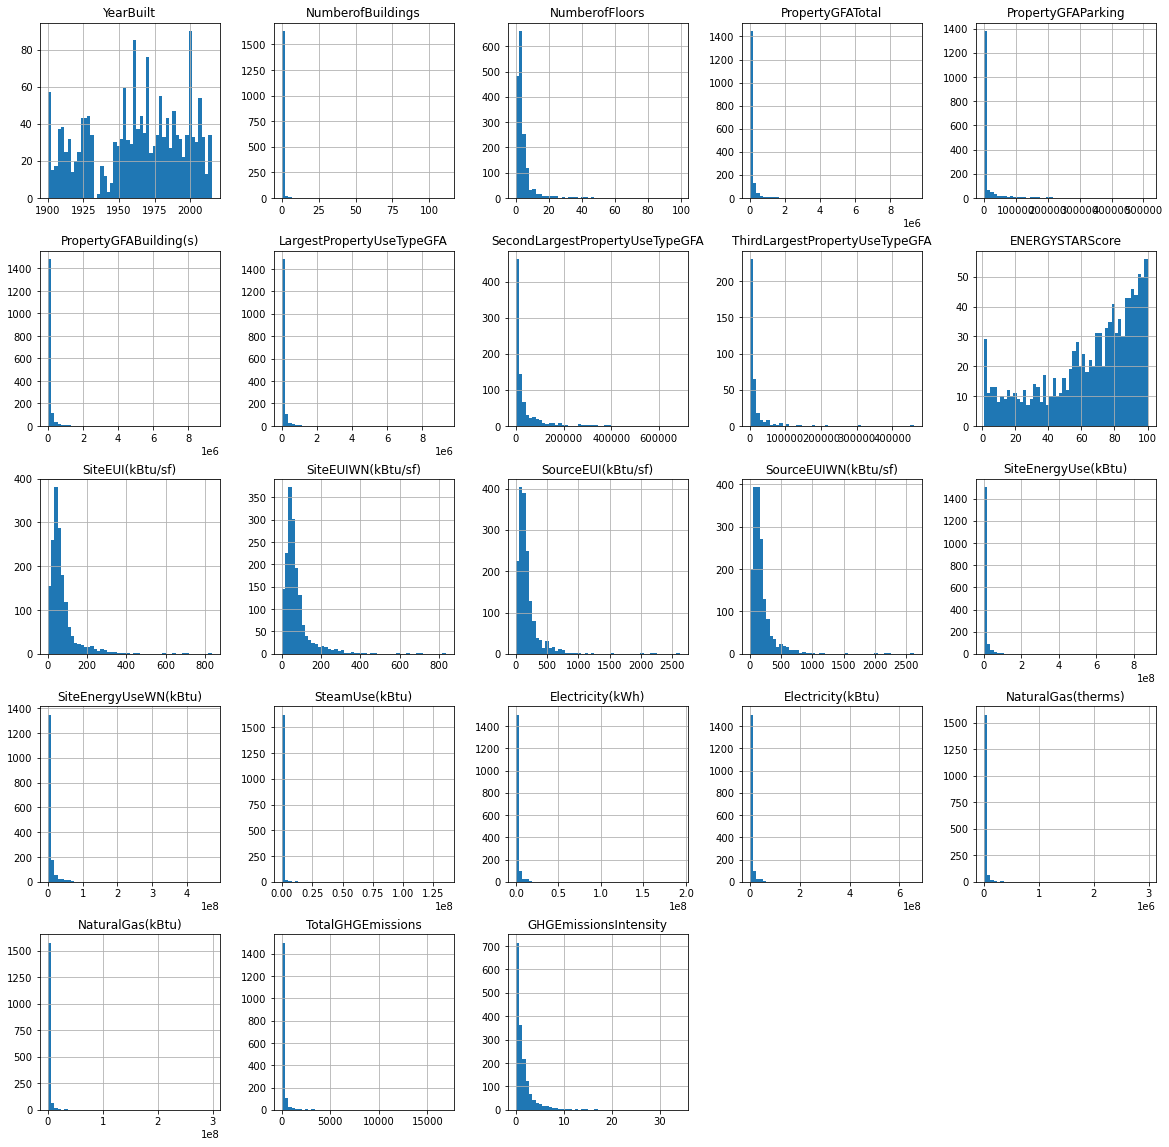

In [72]:
data.hist(column=list_data_quanti,bins=50,figsize=(20,20))
plt.grid()
plt.show()

On ne dénote pas a priori de loi normale sur les histogrammes. La plupart des courbes semblent concentrées sur des valeurs nulles. On pourrait retracer ces courbes sur une échelle logarithmique.
Certaines colonnes semblent identiques mais avec des unités différentes. On ne gardera qu'une seule unité. on peux tracer un graphe d'analyse bivariée ou un tableau des corrélation pour le vérifier.

In [73]:
data.describe()

,CouncilDistrictCode,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,1672.000000,1672.000000,1670.000000,1672.000000,1.672000e+03,1672.000000,1.672000e+03,1.662000e+03,857.000000,352.000000,1102.000000,1669.000000,1669.000000,1670.000000,1670.000000,1.670000e+03,1.669000e+03,1.670000e+03,1.670000e+03,1.670000e+03,1.670000e+03,1.670000e+03,1670.000000,1670.000000
mean,4.366029,1961.888158,1.168263,4.123804,1.190506e+05,13008.352273,1.060422e+05,9.913651e+04,37065.028351,14949.481246,65.435572,72.041282,74.439724,175.800719,178.040060,8.467590e+06,8.097048e+06,5.260323e+05,1.720459e+06,5.870208e+06,1.960594e+04,1.960594e+06,185.654054,1.598629
std,2.189413,32.804629,2.927905,6.558459,2.970683e+05,42501.990861,2.838806e+05,2.768185e+05,70107.477959,36839.886381,28.510255,73.819320,74.783200,185.674647,185.652005,3.022973e+07,2.204537e+07,5.531544e+06,6.091798e+06,2.078522e+07,9.357921e+04,9.357921e+06,752.188402,2.324599
min,1.000000,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-2.100000,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,-0.800000,-0.020000
25%,2.000000,1930.000000,1.000000,1.000000,2.950550e+04,0.000000,2.849800e+04,2.554950e+04,5408.000000,2656.000000,48.000000,33.599998,35.400002,76.400002,79.224998,1.220944e+06,1.293722e+06,0.000000e+00,2.117995e+05,7.226602e+05,0.000000e+00,0.000000e+00,19.882500,0.340000
50%,4.000000,1965.000000,1.000000,2.000000,4.985500e+04,0.000000,4.763750e+04,4.403900e+04,12102.000000,5965.500000,73.000000,51.900002,53.900002,131.150002,134.449997,2.563995e+06,2.699616e+06,0.000000e+00,4.752101e+05,1.621417e+06,4.922630e+03,4.922630e+05,49.580000,0.870000
75%,7.000000,1989.000000,1.000000,4.000000,1.062458e+05,0.000000,9.491200e+04,9.225725e+04,31992.000000,12965.500000,89.000000,81.699997,85.199997,204.075005,205.800003,6.917429e+06,7.204080e+06,0.000000e+00,1.435238e+06,4.897033e+06,1.522715e+04,1.522715e+06,143.102500,1.890000
max,7.000000,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,686750.000000,459748.000000,100.000000,834.400024,834.400024,2620.000000,2620.000000,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,16870.980000,34.090000


Pour palier aux valeurs négatives ou nulles, on choisit d'utiliser une scaler de la librairie scikit-learn appelé PowerTransformer. Cette transformation non linéaire permet de rendre les données plus "Gaussiennes", tout en permettant un centrage en zéro de la moyenne et une normalisation des données.

In [74]:
from sklearn.preprocessing import PowerTransformer
X_scale = PowerTransformer(method="yeo-johnson").fit_transform(data[list_data_quanti])

C:\Users\daims\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())


In [75]:
X_scale

array([[ 0.81432473,  0.03296113,  0.62895983, ..., -1.44347147,
         0.19702639, -1.12436753],
       [-1.58219167,  0.03296113,  1.07251143, ..., -0.24357957,
        -0.05510902, -1.2299028 ],
       [-0.52875295,  0.03296113,  0.62895983, ..., -1.44347147,
         0.54576839, -1.15015363],
       ...,
       [ 0.3005915 ,  0.03296113, -1.15160616, ...,  1.04723953,
         0.97160625,  2.20470268],
       [ 0.81432473,  0.03296113, -1.15160616, ...,  0.29625011,
        -0.55996124,  0.59578501],
       [-0.78005776,  0.03296113, -1.15160616, ...,  0.48473664,
        -0.145085  ,  0.96142874]])

In [76]:
len(X_scale[0])

23

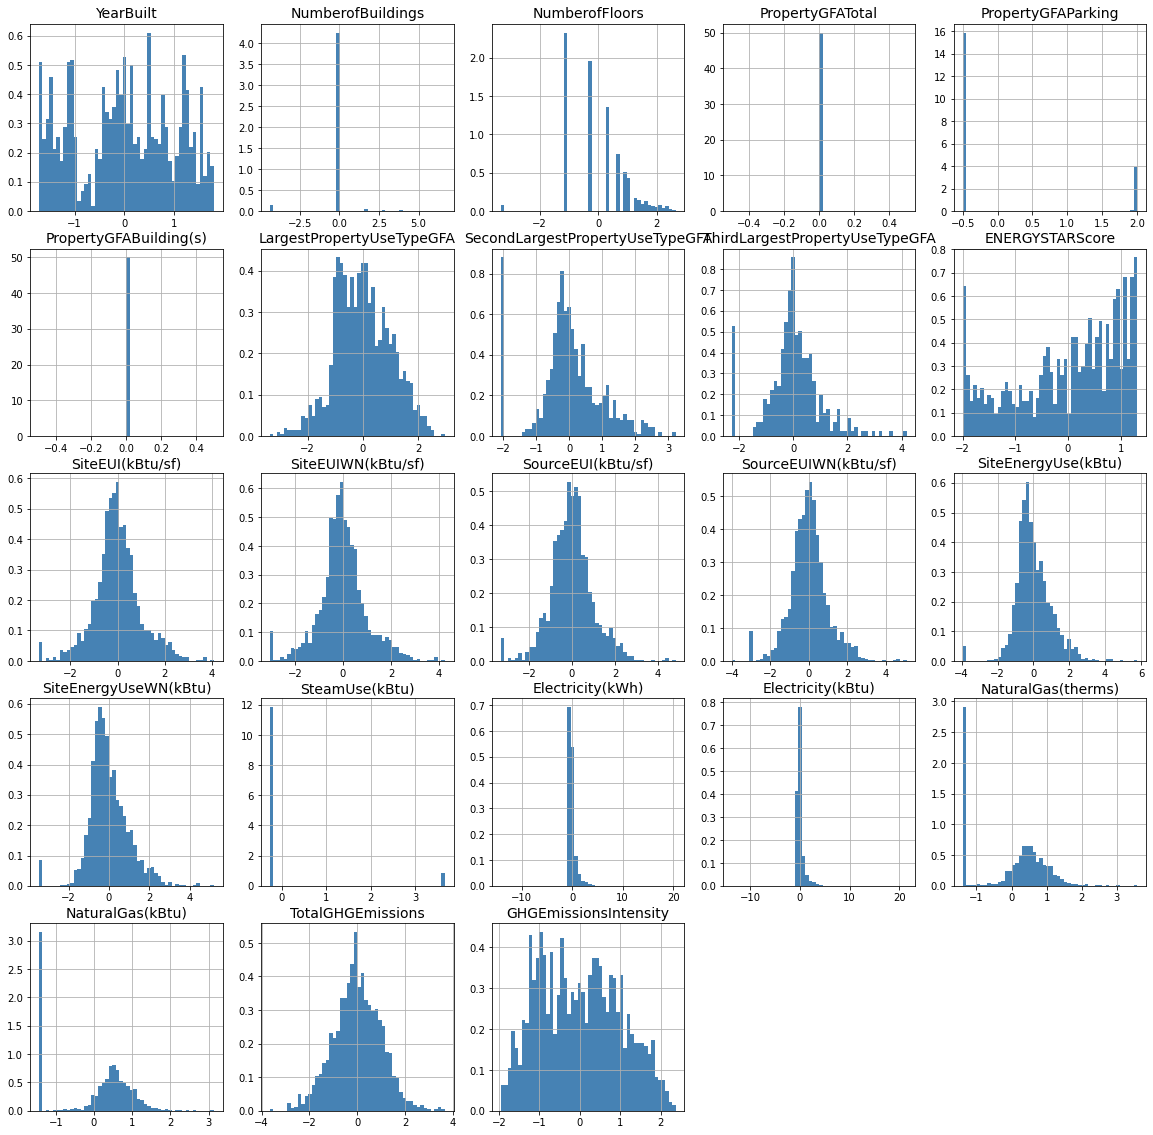

In [77]:
fig = plt.figure(figsize=(20,20))
for feat_idx in range(X_scale.shape[1]):
    ax = fig.add_subplot(5,5, (feat_idx+1))
    h = ax.hist(X_scale[:, feat_idx], bins=50, color='steelblue', density=True, edgecolor='none')
    ax.set_title(data[list_data_quanti].columns[feat_idx], fontsize=14)
    plt.grid()


In [78]:
# yj = PowerTransformer(method='yeo-johnson') 
# data[list_data_quanti].transform(yj)

Sur une cette nouvelle échelle, on constate des comportements de type loi normale, notamment sur les données liées à l'énergie et à l'émission de gazs.  
Les pics qu'on dénote en zéro sont dûes à la valeur 1 ajoutée dans chaque fonction logarithmique.

# Analyse bivariée
## Matrice des corrélations

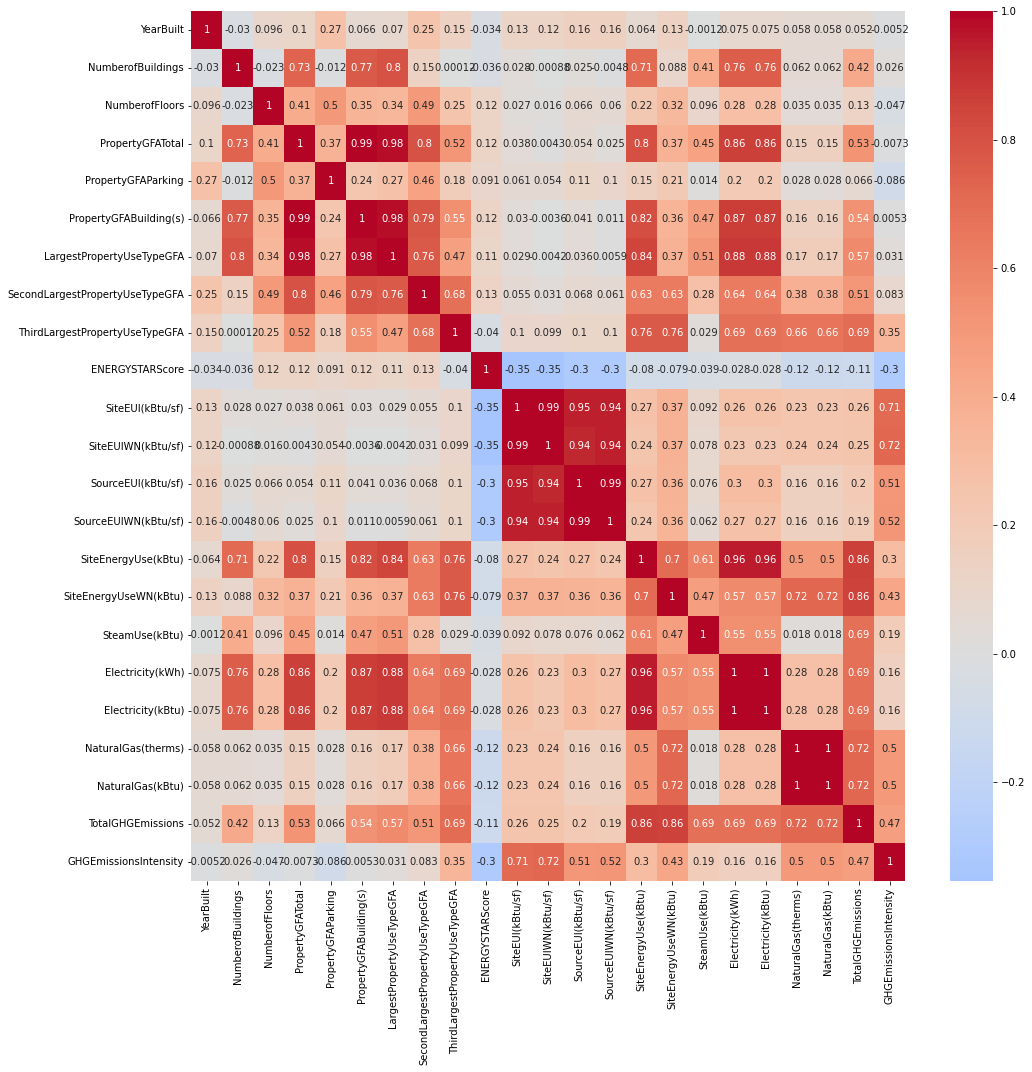

In [79]:
plt.figure(figsize=(16, 16))
sns.heatmap(data[list_data_quanti].corr(), annot=True,center=0,cmap="coolwarm")
plt.show()

La matrice de corrélation nous permet de voir quelles sont les variables qui sont très linéairement corrélées avec d'autres variables.   
Sachant que la variable cible à prédire correspond à "SiteEnergyUse(kBtu)" et qu'on doit la prédire avec des variables qui ne représentent pas l'énergie, on va mettre de côté toute les colonnes d'énergies (celles en dessous de la lignes "ENERGYSTARScore" de l'axe des ordonnées de gauche), et regarder les variables les plus corrélées avec "SiteEnergyUse(kBtu)" (ou SiteEnergyUseWN(kBtu) qui corrige l'effet lié à la température (chauffages, ...)).

On pourra effectuer un raisonnmeent similaire pour la variable à prédire "TotalGHGEmissions".

- "DataYear" ne nous apporte peu d'informations et est très peu corrélées à la variable cible à prédire.
- "YearBuilt" est très peu corrélée à la variable à prédire cepepndant cette donnée peut-être intéressante pour comprendre et interpréter certaines variables.
- "CouncilDistrictCode" pourrait nous indiquer s'il y a un lien entre la localisation du bâtiment et sa consommation énergétique, mais semble très peu corrélée à la valeur cible.  
- "NumberofBuildings" semble assez bien corrélé (>60%) mais il faudrait comprendre à quoi correspond réellement ce nombre, si l'on considère que chaque ligne ou individu de la base de données ne représente qu'un seul bâtiment!  
- "NumberofFloors" semble peu corrélée à "SiteEnergyUse(kBtu)" (21%) alors qu'elle pourrait être une variable intéressante à garder.  

#### Apparté:  
- 'SiteEnergyUseWN(kBtu)': Peut être utilisé comme variable cible à prédire car elle représente 'SiteEnergyUse(kBtu)' avec une considération de larégularisation de l'énerge thermique des bâtiments.
- 'TotalGHGEmissions': Sera utilisé comme variable cîble dans un autre notebook de prédiction pour prédire les émissions de gazs générés par les bâtiments.
- 'ENERGYSTARScore': Sera utilisé dans un autre notebook de prédiction comme variable explicative pour voir son influence sur la prédiction de la variable cible 'SiteEnergyUseWN(kBtu)'.


## Choix des colonnes quantitatives

In [155]:
list_data_quanti_keep = ['YearBuilt','NumberofBuildings', 'NumberofFloors',
       'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA','ENERGYSTARScore','SiteEnergyUse(kBtu)','SiteEnergyUseWN(kBtu)', 'TotalGHGEmissions']

In [156]:
list_keep = list_data_quanti_keep + list_data_quali_keep

In [157]:
list_keep

['YearBuilt',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseTypeGFA',
 'ENERGYSTARScore',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'TotalGHGEmissions',
 'BuildingType',
 'PrimaryPropertyType',
 'LargestPropertyUseType',
 'SecondLargestPropertyUseType',
 'ThirdLargestPropertyUseType',
 'CouncilDistrictCode']

# Gestion des données manquantes (ou NaN)
## Suppression des lignes et colonnes complètent de NaN

Suppression des lignes ne possédant que des cellules vides.

In [158]:
data = data.dropna(axis=1,how='all') #on supprime les colonnes composées que de NaN dans chaque cellule

In [159]:
update_shape = data.shape
update_shape

(1672, 30)

## Suppression des faibles pourcentages
Evaluation du taux de remplissage des colonnes.

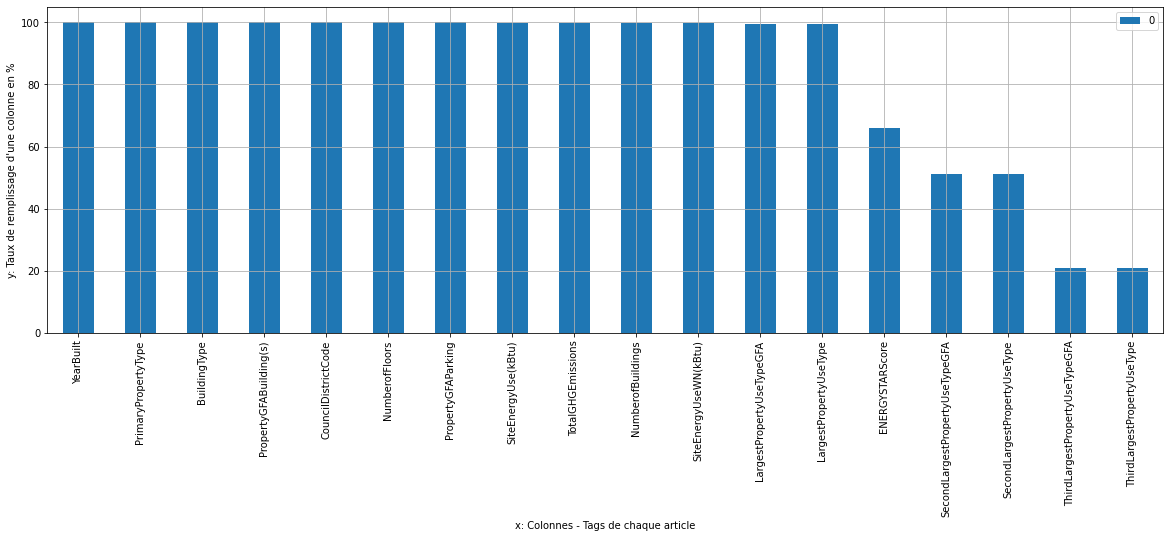

,0
YearBuilt,100.000000
PrimaryPropertyType,100.000000
BuildingType,100.000000
PropertyGFABuilding(s),100.000000
CouncilDistrictCode,100.000000
NumberofFloors,100.000000
PropertyGFAParking,100.000000
SiteEnergyUse(kBtu),99.880383
TotalGHGEmissions,99.880383
NumberofBuildings,99.880383


In [85]:
fillrate(data[list_keep],1)

Les colonnes "NumberofBuildings", "LargestPropertyUseTypeGFA", "LargestPropertyUseType" et "SiteEnergyUse(kBtu)" et "TotalGHGEmissions" sont remplies à plus de 99%. On décide arbitrairement de supprimer les lignes correspondant à ces 1% de vide.

In [160]:
#data = data.dropna(axis=1,how='all') #on supprime les colonnes composées que de NaN dans chaque cellule
#on supprime les lignes possédant au moins une cellule vide
data.dropna(subset=["NumberofBuildings","LargestPropertyUseTypeGFA","LargestPropertyUseTypeGFA","SiteEnergyUse(kBtu)","SiteEnergyUseWN(kBtu)", "TotalGHGEmissions"],inplace=True)

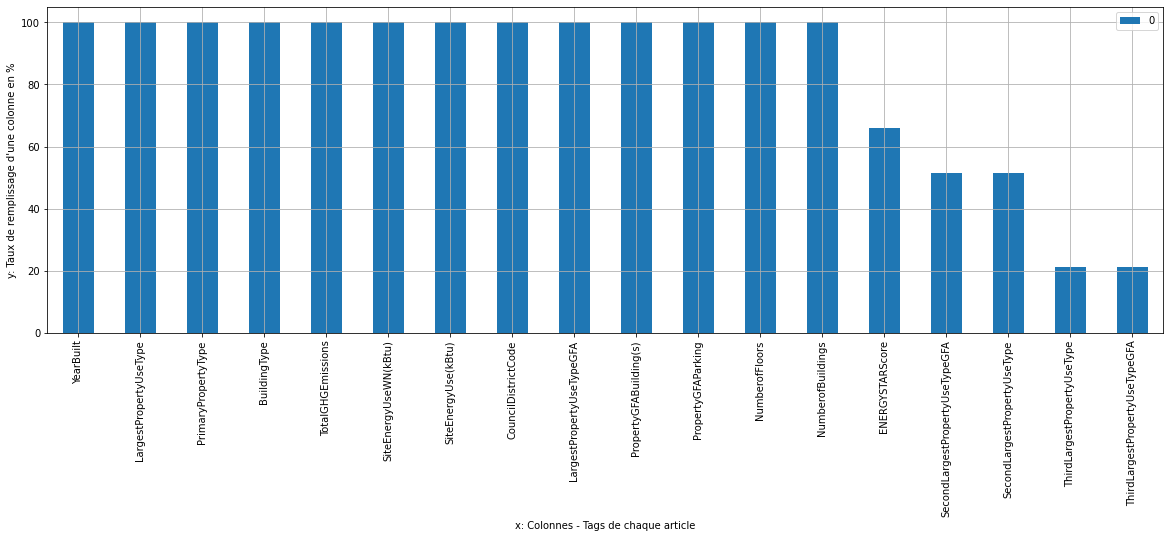

,0
YearBuilt,100.000000
LargestPropertyUseType,100.000000
PrimaryPropertyType,100.000000
BuildingType,100.000000
TotalGHGEmissions,100.000000
SiteEnergyUseWN(kBtu),100.000000
SiteEnergyUse(kBtu),100.000000
CouncilDistrictCode,100.000000
LargestPropertyUseTypeGFA,100.000000
PropertyGFABuilding(s),100.000000


In [87]:
fillrate(data[list_keep],1)

## Imputation métier
Les nan des colonnes "PropertyUseTypeGFA" semblent correspondrent aux nan des colonnes "PropertyUseType" lorsqu'il n'y a pas de seconde ou troisième utilisation d'un bâtiment en particulier. On décide de mettre ces nan à 0 correspondant à 0 GFA utilisé lorsque "PropertyUseTypeGFA" est un nan (ou "Not Used"). On préfère évidemment cette méthode plutôt que de remplacer les nan par des 0, pour s'assurer de la correspondance entre la colonne qualitative et la colonne quantitative GFA.

In [168]:
# Retourne la valeur numérique 0 s'il y a un nan dans la valeur de la colonne "col_name" à l'indice "indexe"

def nan2zero(indexe, col_name,dataframe,col_num_data):
    if pd.isna(dataframe[col_name].iloc[indexe])==True or (dataframe[col_name].iloc[indexe] =="Not Used"):
        return 0
    else:
        return dataframe[col_num_data].iloc[indexe]
    #return dataframe[col_name].iloc[indexe]

In [169]:

def imputation_zero(dataframe,column_data_num,column_data_quali):
    data_upd = dataframe.copy()
    i=0
    for col_data in column_data_num:
        col_data_quali = column_data_quali[i]
        data_upd[col_data] = [nan2zero(indexe, col_data_quali,data_upd,col_data) for indexe in range(data_upd.shape[0])] # si on utilise iloc dans nan2zero
        #data_upd[col_data] = [nan2zero(indexe, col_data,data_upd) for indexe in data_upd.index.to_list()] # si on utilise loc dans nan2zero
        # ici on a modifier la liste dont appartient les indexe
        print(str(col_data))
        i+=1
    return data_upd

In [170]:
# column_data_num_gfa = ['LargestPropertyUseTypeGFA','SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA']
# column_data_quali_gfa = ['LargestPropertyUseType','SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']

column_data_num_gfa = ['SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA']
column_data_quali_gfa = ['SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']

data_en = imputation_zero(data,column_data_num_gfa,column_data_quali_gfa)

SecondLargestPropertyUseTypeGFA
ThirdLargestPropertyUseTypeGFA


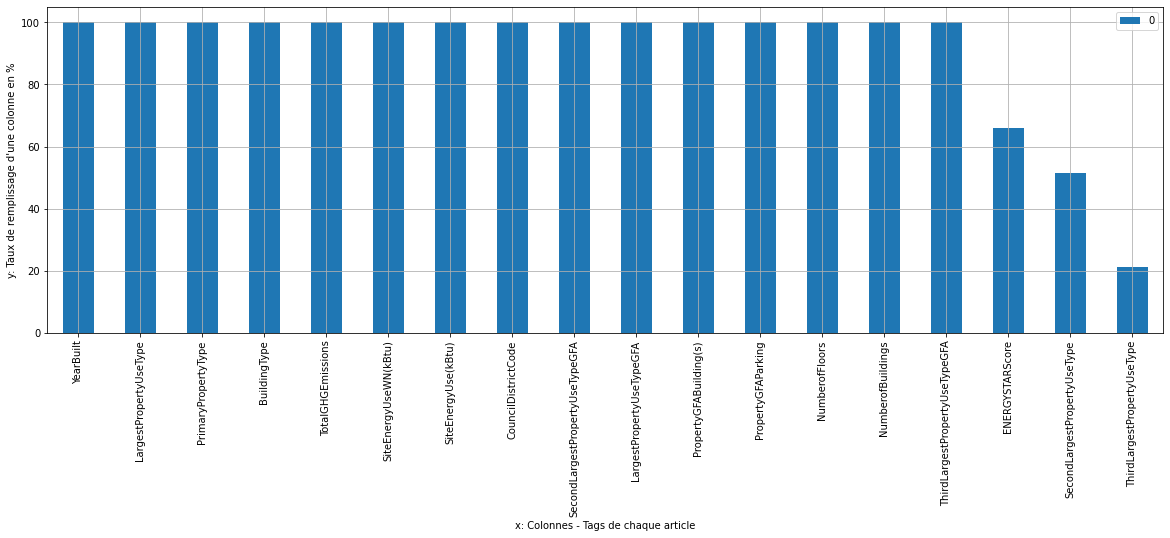

,0
YearBuilt,100.000000
LargestPropertyUseType,100.000000
PrimaryPropertyType,100.000000
BuildingType,100.000000
TotalGHGEmissions,100.000000
SiteEnergyUseWN(kBtu),100.000000
SiteEnergyUse(kBtu),100.000000
CouncilDistrictCode,100.000000
SecondLargestPropertyUseTypeGFA,100.000000
LargestPropertyUseTypeGFA,100.000000


In [175]:
fillrate(data_en[list_keep],1)

Vérifions qu'on a pu réussir à bien remplir les colonnes qui nous intéressait en déterminant s'il existe encore des colonnes qui répondent à notre problématique de remplissage:

In [116]:
# On récupère les indexes des lignes de
index_gfa_nan_and_nan_data_en = data[((data_en["SecondLargestPropertyUseType"] == np.nan) | ( (pd.isna(data_en["SecondLargestPropertyUseType"])) ) ) & \
          (( (data_en["SecondLargestPropertyUseTypeGFA"] == np.nan) ) | pd.isna(data_en["SecondLargestPropertyUseTypeGFA"]) )].index

In [117]:
len(index_gfa_nan_and_nan_data_en)

0

La fonction de remplissage est donc bien passée et le taux de remplissge pour les colonnes de type GFA est monté à 100%. Il n'y a plus de NaN présents dans ces colonnes.

In [176]:
data_en[list_keep].isnull().sum(axis=0)

YearBuilt                             0
NumberofBuildings                     0
NumberofFloors                        0
PropertyGFAParking                    0
PropertyGFABuilding(s)                0
LargestPropertyUseTypeGFA             0
SecondLargestPropertyUseTypeGFA       0
ThirdLargestPropertyUseTypeGFA        0
ENERGYSTARScore                     565
SiteEnergyUse(kBtu)                   0
SiteEnergyUseWN(kBtu)                 0
TotalGHGEmissions                     0
BuildingType                          0
PrimaryPropertyType                   0
LargestPropertyUseType                0
SecondLargestPropertyUseType        805
ThirdLargestPropertyUseType        1309
CouncilDistrictCode                   0
dtype: int64

## Relation entre colonnes

On aimerait discuter ici des relations entre les colonnes.

On a par les relations suivantes qui semblent se présenter:

- PropertyGFATotal = PropertyGFAParking + PropertyGFABuilding(s)
- PropertyGFABuilding(s) =/= LargestPropertyUseTypeGFA mais proche. De ce qu'on constate, il n'y a pas nécessairement de relation de supériorité ou d'inférioté entre les deux grandeurs.  

Cependant, comme on ne peut pas s'assurer de la véracité de ces résultats, on décide de laisser comme tel et de travailler une autre approche qui pourra nous aider à réaliser ces prédictions.

### Création de variables  
On décide de créer de nouvelles variables à partir des anciennes, qui seront non linéaires aux variables originales:

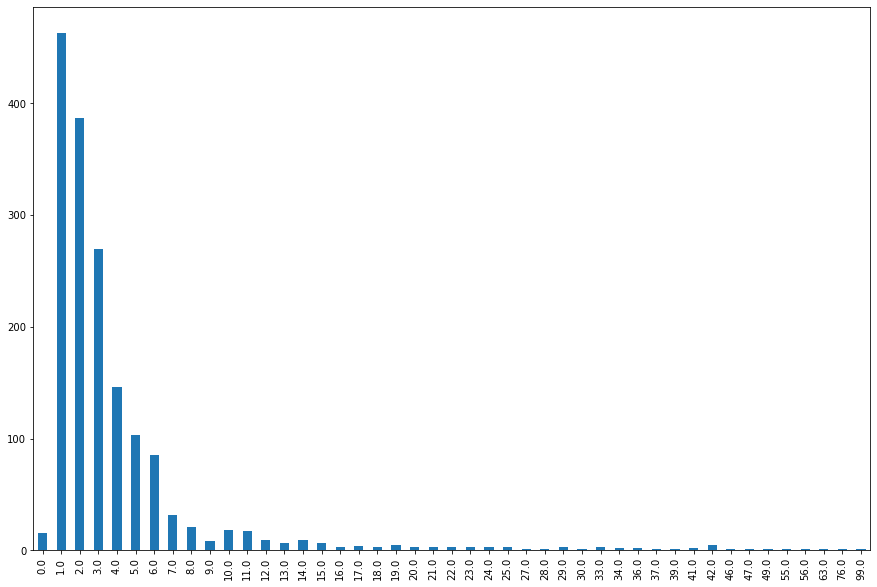

In [184]:
plt.figure(figsize=(15,10))
data_en['NumberofFloors'].value_counts().sort_index().plot.bar()
plt.show()

La valeur nulle pour la variable "NumberofFloors" existe.

In [185]:
np.min(data_en['LargestPropertyUseTypeGFA'].values)

5656.0

In [186]:
data_en['NbFloorsByLargestGFA'] = data_en['NumberofFloors'] / data_en['LargestPropertyUseTypeGFA']
data_en['NbFloorSquare'] = data_en['NumberofFloors'] **2
data_en['LargestGFASquare'] = data_en['LargestPropertyUseTypeGFA'] **2
data_en['LargestGFAByNbFloors'] = data_en['LargestPropertyUseTypeGFA'] / (1+data_en['NumberofFloors'])
data_en['PropertyGFABuildingByNbFloors'] = data_en['PropertyGFABuilding(s)'] / (1+data_en['NumberofFloors'])

list_quanti_bonus = ['NbFloorsByLargestGFA','NbFloorSquare','LargestGFASquare','LargestGFAByNbFloors','PropertyGFABuildingByNbFloors']

On évalue leur corrélation vis-à-vis des variables cibles à prédire.

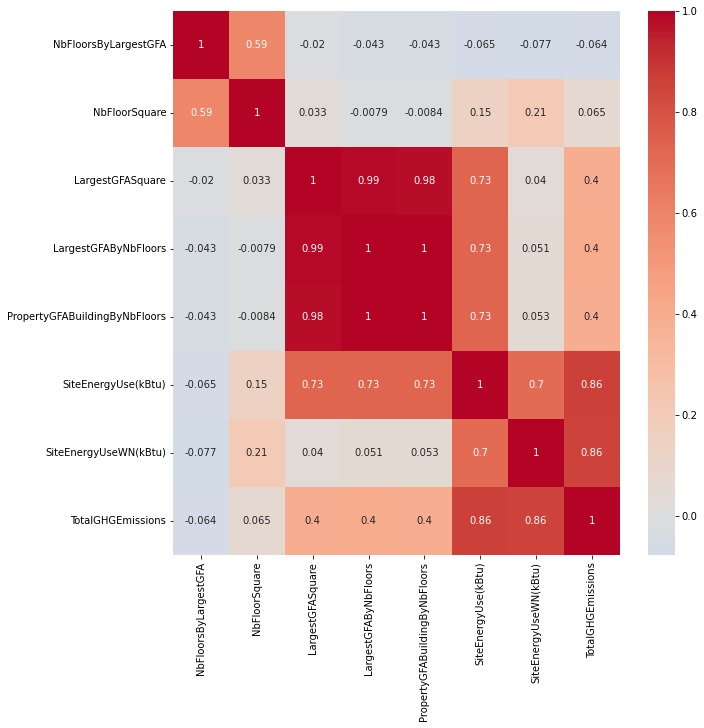

In [187]:
list_data_bonus_corr = list_quanti_bonus+['SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'TotalGHGEmissions']
plt.figure(figsize=(10, 10))
sns.heatmap(data_en[list_data_bonus_corr].corr(), annot=True,center=0,cmap="coolwarm")
plt.show()

On constate des corrélations assez dispersées d'une variable à l'autre, ce qui donne une map très hétérogène, qu'on pourra utilsé par la suite.

In [188]:
list_data_quanti_keep + list_quanti_bonus

['YearBuilt',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseTypeGFA',
 'ENERGYSTARScore',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'TotalGHGEmissions',
 'NbFloorsByLargestGFA',
 'NbFloorSquare',
 'LargestGFASquare',
 'LargestGFAByNbFloors',
 'PropertyGFABuildingByNbFloors']

In [203]:
# plt.figure(figsize=(16, 16))
# sns.heatmap(data_en[list_data_quanti_keep + list_quanti_bonus].corr(), annot=True,center=0,cmap="coolwarm")
# plt.show()

# Sauvegarde du dataset nettoyé
On sauvegarde le nouveau dataset

In [190]:
# saving the dataframe
data_en[list_keep + list_quanti_bonus].to_csv('D:\\Utilisateurs\\Damien\\Documents\\Test_code\\test_python\\OCR_projets\\IML\\P3_\\data_clean.csv', sep='\t', index=False)